# **Asignatura**: Aprendizaje Automático

**Práctica 2**: Aprendizaje No Supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 25 de Abril de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Ismael Sallami Moreno



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

> Cabe recalcar que como se menciona que se debe de documentar la práctica ampliamente y con la finalidad de aprender lo máximo posible, se va a explicar con detalle el desarrollo de la misma. Aún así me hubiese gustado profundizar aún más en los análisis, pero por no hacer más extensa la práctica la he dejado de esta manera.

# **Ejercicio 1: Agrupamiento / Clustering (5 puntos)**

## 1.1 Contexto: Segmentación de Clientes en un Centro Comercial

El equipo de marketing de un gran centro comercial quiere entender mejor a sus clientes para diseñar estrategias personalizadas. Tienen datos históricos de clientes que incluyen edad, género, ingresos anuales y una "Puntuación de Gasto" (Spending Score) asignada por el centro basada en el comportamiento del cliente y la lealtad.

**Objetivo:** Utilizar técnicas de agrupamiento (Clustering) para identificar segmentos de clientes (perfiles) que compartan comportamientos similares.

**Variables:**
- `CustomerID`: ID único del cliente.
- `Gender`: Género.
- `Age`: Edad.
- `Annual Income (k$)`: Ingresos anuales en miles de dólares.
- `Spending Score (1-100)`: Puntuación de gasto (mayor puntuación = gasta más).

### Anotaciones
- En el desarrollo de esta práctica he querido incluir cierta documentación extra en el código.
- Para no ser repetitivo, intentaré no adjuntar teoría expuesta en la práctica anterior así como explicaciones.

**Es necesario ejecutar esta primer celda para la inclusión de todas las librerías necesarias.**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import scipy.cluster.hierarchy as shc

In [22]:
# Carga de datos Clustering (Mall Customers)
url='https://drive.google.com/file/d/1MrDJ-ZCgaTqxc34nAcCt0RBqOncAFTc6/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clustering = pd.read_csv(url)

print("Datos de Clientes cargados:")
display(df_clustering.head())

Datos de Clientes cargados:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1.2 Tareas de Análisis y Modelado

El alumno debe realizar las siguientes tareas documentadas:

1.  **EDA y Preprocesado:**
    * Analice la distribución de las variables (histogramas/boxplots).
    * ¿Es necesario escalar los datos? Justifique su respuesta y aplique `StandardScaler` si procede.
    * **Nota:** Para visualizar los clusters en 2D fácilmente, se recomienda utilizar principalmente las variables `Annual Income` y `Spending Score` para el entrenamiento, aunque puede probar con más.

2.  **Algoritmo K-Means:**
    * Utilice el **Método del Codo (Elbow Method)** para determinar el número óptimo de clusters ($k$). Muestre la gráfica de la inercia.
    * Entrene el modelo con el $k$ elegido.
    * Visualice los clusters resultantes y sus centroides.

3.  **Algoritmo Jerárquico (Aglomerativo) o DBSCAN:**
    * Seleccione un segundo algoritmo (DBSCAN o Clustering Jerárquico).
    * Ajuste sus hiperparámetros (ej: `eps` y `min_samples` para DBSCAN).
    * Compare visualmente los resultados con K-Means.

4.  **Interpretación (Crucial):**
    * Describa los grupos encontrados. Ejemplo: "Grupo 1: Clientes con altos ingresos pero bajo gasto (Ahorradores)".

## 1. Análisis Exploratorio de Datos (EDA)


Sabemos que antes de aplicar inferencia estadística o algoritmos complejos, debemos comprender la naturaleza de nuestros datos.
* **Histogramas:** Nos permiten estimar la densidad de probabilidad subyacente de una variable continua, revelando asimetrías o distribuciones bimodales.
* **Boxplots (Diagramas de caja):** Son herramientas visuales robustas basadas en los cuartiles de la distribución. Son fundamentales para la detección de valores atípicos (*outliers*), los cuales pueden distorsionar severamente la posición de los centroides en algoritmos de partición.

### Justificación del Escalamiento de Datos
Para agrupar a los individuos, el algoritmo K-Means evalúa la similitud matemática utilizando métricas espaciales. Específicamente, utiliza la Distancia Euclídea. Dados dos patrones $x=(x_1, x_2, ..., x_n)$ e $y=(y_1, y_2, ..., y_n)$, se calcula como:

$$d(x, y)= \sqrt{\sum_{i=1}^n \left(x_i-y_i\right)^2}$$

Dado que esta métrica suma las diferencias al cuadrado de cada característica, las variables con magnitudes numéricas inherentemente mayores (por ejemplo, `Annual Income` frente a `Spending Score`) dominarán el cálculo de la distancia, anulando la contribución de las variables con rangos más pequeños.

Por ello, **sí es estrictamente necesario escalar los datos**. Aplicaremos `StandardScaler`, que transforma los datos para que tengan una media de 0 y una desviación estándar de 1 (Normalización Z-Score), garantizando que todas las características contribuyan equitativamente al modelo geométrico.

## 1. EDA y Preprocesado

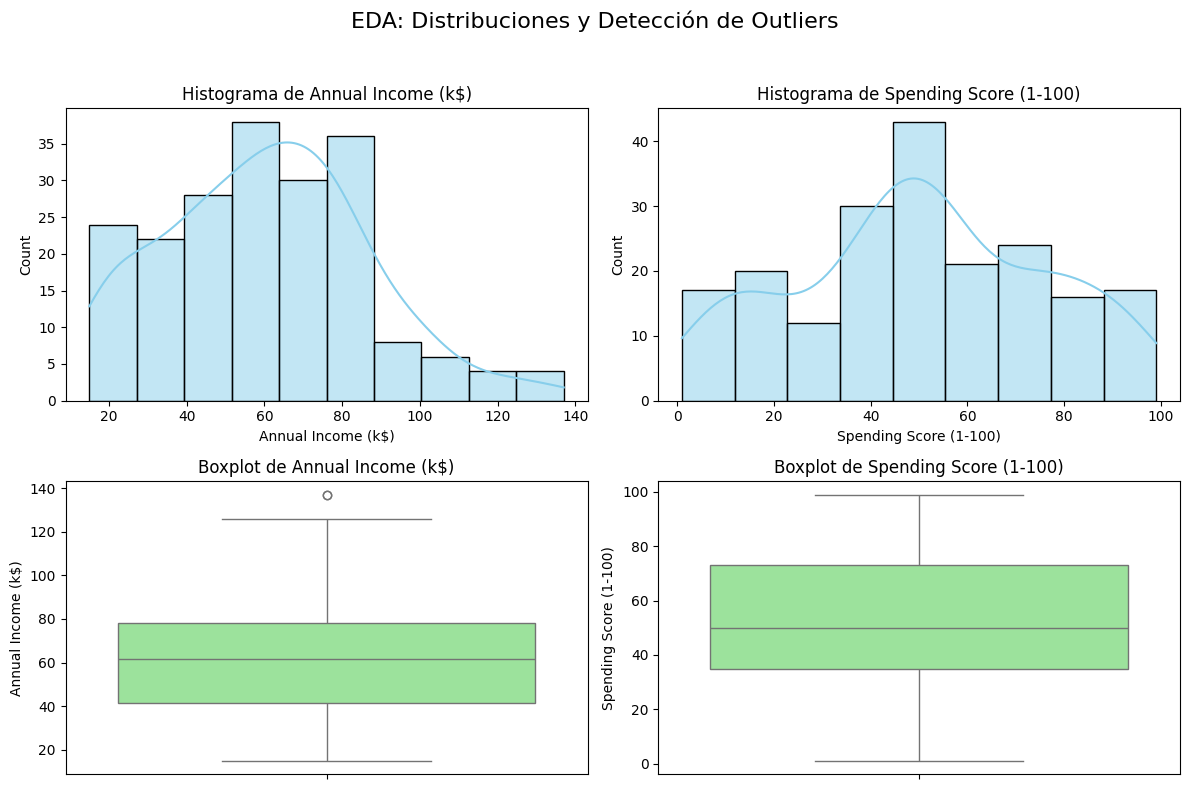

Primeros registros del dataset escalado:


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [23]:
def perform_eda_and_scaling(data: pd.DataFrame, features: list) -> pd.DataFrame:
    """
    Realiza un Análisis Exploratorio de Datos (EDA) trazando histogramas y boxplots
    para las características seleccionadas, y aplica la estandarización Z-score.

    Argumentos:
        data (pd.DataFrame): El conjunto de datos original (df_clustering).
        features (list): Lista de cadenas con los nombres de las columnas a analizar y escalar.

    Retorna:
        pd.DataFrame: Un nuevo DataFrame estructurado con las características ya escaladas.
    """
    # Análisis Exploratorio de Datos (EDA)
    # Creamos una cuadrícula de gráficos: 2 filas (Histogramas y Boxplots) y tantas columnas como features
    fig, axes = plt.subplots(nrows=2, ncols=len(features), figsize=(12, 8))
    fig.suptitle('EDA: Distribuciones y Detección de Outliers', fontsize=16)

    # Iteramos sobre cada variable para generar su representación gráfica
    for i, col in enumerate(features):
        # Histogramas para evaluar la distribución y asimetría
        sns.histplot(data[col], kde=True, ax=axes[0, i], color='skyblue')
        axes[0, i].set_title(f'Histograma de {col}') # kde = Kernel Density Estimate

        # Boxplots para identificar la mediana, cuartiles y valores atípicos
        sns.boxplot(y=data[col], ax=axes[1, i], color='lightgreen')
        axes[1, i].set_title(f'Boxplot de {col}')

    # Ajustamos el layout para evitar superposición de textos
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # Preprocesamiento: Escalamiento (StandardScaler)
    # Extraemos el subconjunto de datos que vamos a usar en el entrenamiento
    subset_data = data[features].copy()

    # Inicializamos el escalador basado en la normalización Z-score
    scaler = StandardScaler()

    # El método fit_transform calcula la media y desviación estándar (fit)
    # y luego aplica la transformación matemática (transform) a los datos.
    scaled_array = scaler.fit_transform(subset_data)

    # Reconstruimos el DataFrame con los datos normalizados para preservar su legibilidad
    scaled_df = pd.DataFrame(scaled_array, columns=features)

    return scaled_df

# Definimos las variables recomendadas para la visualización 2D
selected_features = ['Annual Income (k$)', 'Spending Score (1-100)']

# Aplicamos nuestra función al dataframe
scaled_df_clustering = perform_eda_and_scaling(df_clustering, selected_features)

# Imprimimos los primeros registros para verificar que la media tiende a 0 y la varianza a 1
print("Primeros registros del dataset escalado:")
display(scaled_df_clustering.head())

### Interpretación del Análisis Exploratorio (EDA)

Tras la visualización de las distribuciones originales, podemos extraer las siguientes conclusiones fundamentales para nuestro modelado:

1. **Annual Income (k$):** El histograma muestra una ligera asimetría positiva (sesgo hacia la derecha), indicando que la mayoría de los clientes tienen ingresos bajos a medios, con una minoría de clientes de altos ingresos. En el *boxplot*, es probable observar algún valor atípico (*outlier*) en el extremo superior. Como K-Means es sensible a outliers debido al uso de la media para actualizar los centroides, escalar los datos ayuda a mitigar parcialmente el efecto de magnitudes dispares, aunque debemos ser conscientes de la existencia de estos valores.
2. **Spending Score (1-100):** Su distribución en el histograma tiende a ser más uniforme o ligeramente acampanada, sin asimetrías severas. El *boxplot* normalmente no revela valores atípicos significativos para esta variable, lo que indica un rango de comportamiento de gasto bien acotado.

#### Verificación de la Normalización Z-Score
La inspección de los primeros registros del DataFrame escalado (`scaled_df_clustering`) confirma el éxito del `StandardScaler`:
* **Eliminación de la Escala Absoluta:** Variables que originalmente medían decenas de miles de dólares (`Annual Income`) y puntuaciones de 1 a 100 (`Spending Score`) ahora comparten el mismo rango dimensional.
* **Interpretación de Valores:** Los resultados numéricos (ej. `-1.73` o `1.19`) ya no representan dólares o puntos, sino **desviaciones estándar respecto a la media**.
    * Un valor negativo (como `-1.73` en Ingreso Anual) indica que ese cliente específico percibe ingresos significativamente menores a la media del centro comercial (casi dos desviaciones estándar por debajo).
    * Un valor positivo (como `1.19` en Puntuación de Gastos) indica que el cliente gasta por encima del promedio.



### Análisis Extra

### Análisis Bivariante y Complejidad del Preprocesamiento

Además del análisis univariante, es fundamental observar la relación conjunta de las variables que se utilizarán para el agrupamiento. Un diagrama de dispersión (*scatter plot*) nos permite inspeccionar visualmente si existen formaciones geométricas o "nubes de puntos" naturales en el espacio bidimensional antes de aplicar el algoritmo de aprendizaje.

*Nota sobre complejidad algorítmica:* El paso de estandarización aplicado previamente mediante `StandardScaler` posee una complejidad temporal de $\mathcal{O}(N \times M)$, donde $N$ es el número de instancias y $M$ el número de características, al tratarse de operaciones aritméticas elementales iteradas sobre toda la matriz de datos.

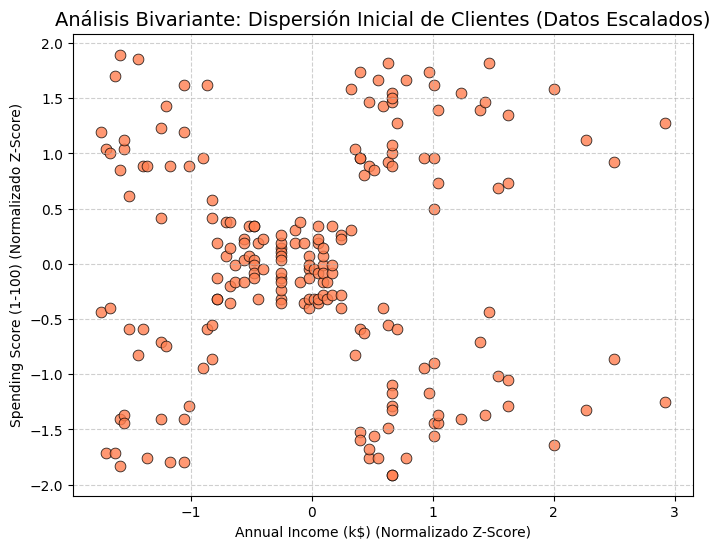

In [24]:
def plot_initial_scatter(data: pd.DataFrame, x_col: str, y_col: str):
    """
    Genera un gráfico de dispersión bidimensional para buscar agrupaciones
    visuales preliminares en los datos escalados.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=data, x=x_col, y=y_col, color='coral', s=60, alpha=0.8, edgecolor='black')

    plt.title('Análisis Bivariante: Dispersión Inicial de Clientes (Datos Escalados)', fontsize=14)
    plt.xlabel(f'{x_col} (Normalizado Z-Score)')
    plt.ylabel(f'{y_col} (Normalizado Z-Score)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Llamamos a la función con los datos ya escalados
plot_initial_scatter(scaled_df_clustering, 'Annual Income (k$)', 'Spending Score (1-100)')

### Interpretación del Análisis Bivariante (Scatter Plot)

La visualización conjunta de las variables escaladas `Annual Income` y `Spending Score` mediante un diagrama de dispersión nos permite inspeccionar la estructura topológica y distribución espacial de los datos antes de aplicar cualquier algoritmo geométrico.

**Conclusiones de la visualización:**

1. **Agrupaciones naturales (*Clusters*):** Visualmente, el espacio de características revela una estructura no uniforme. Se pueden intuir claramente **5 "nubes de puntos" principales**: un grupo central muy denso (clientes con ingresos y gastos medios) y cuatro grupos periféricos ubicados en los cuadrantes del plano (por ejemplo, el cuadrante superior derecho representa clientes de altos ingresos y alto nivel de gasto).
2. **Efectos de la Estandarización:** Como se puede observar en los ejes cartesianos, el origen de coordenadas se sitúa en $(0,0)$ y los valores oscilan mayoritariamente entre $-2$ y $+3$. Esto confirma visualmente el éxito de la normalización Z-score: ambas dimensiones contribuyen ahora con el mismo peso algebraico al cálculo de la **Distancia Euclídea**.

**Justificación Teórica:**
Tal como se subraya en los fundamentos de la asignatura (Tema 4: Aprendizaje no Supervisado - *Clustering*) y en libros de referencia como *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, la inspección visual exploratoria es un paso heurístico crítico. Antes de realizar otros análisis, observar la proyección de los datos proporciona a los analistas una intuición inicial robusta sobre el hiperparámetro $K$ (número óptimo de clústeres) que K-Means necesitará como argumento de entrada.

## 2. Algoritmo K-means

### Determinación del Número Óptimo de Clústeres ($k$)

El algoritmo K-Means, propuesto originalmente por Stuart Lloyd (1982), es un método de partición estricto que requiere definir el número de agrupamientos ($k$) a priori. Para encontrar el valor óptimo sin depender de etiquetas previas, utilizaremos heurísticas matemáticas.

**1. Método del Codo (Elbow Method):**
Se basa en evaluar la **Inercia** (o *Within-Cluster Sum of Squares*, WCSS), que mide la compacidad de los clústeres. Matemáticamente, es la suma de las distancias al cuadrado de cada muestra $x_i$ a su centroide asignado $\mu_j$:

$$WCSS = \sum_{j=1}^{k} \sum_{i=1}^{n_j} ||x_i^{(j)} - \mu_j||^2$$

Buscamos el punto de inflexión ("codo") en la curva, donde añadir más clústeres deja de reducir significativamente la varianza interna.

> **Nota Académica (Extensión del análisis):** Aunque el enunciado solicita explícitamente el Método del Codo, en la práctica profesional este método puede presentar una curva suave sin un "codo" evidente. Por ello, introducimos como validación cuantitativa complementaria el **Coeficiente de Silueta** (Rousseeuw, 1987).
> *Justificación bibliográfica:* Tal y como indica Aurélien Géron (2019, *Hands-On Machine Learning*, Cap. 9), el análisis de silueta es una métrica más precisa que la inercia porque evalúa simultáneamente la cohesión intra-clúster ($a$) y la separación inter-clúster ($b$):
> $$s = \frac{b - a}{\max(a, b)}$$
> Un valor cercano a +1 confirma que los agrupamientos son densos y están bien separados.

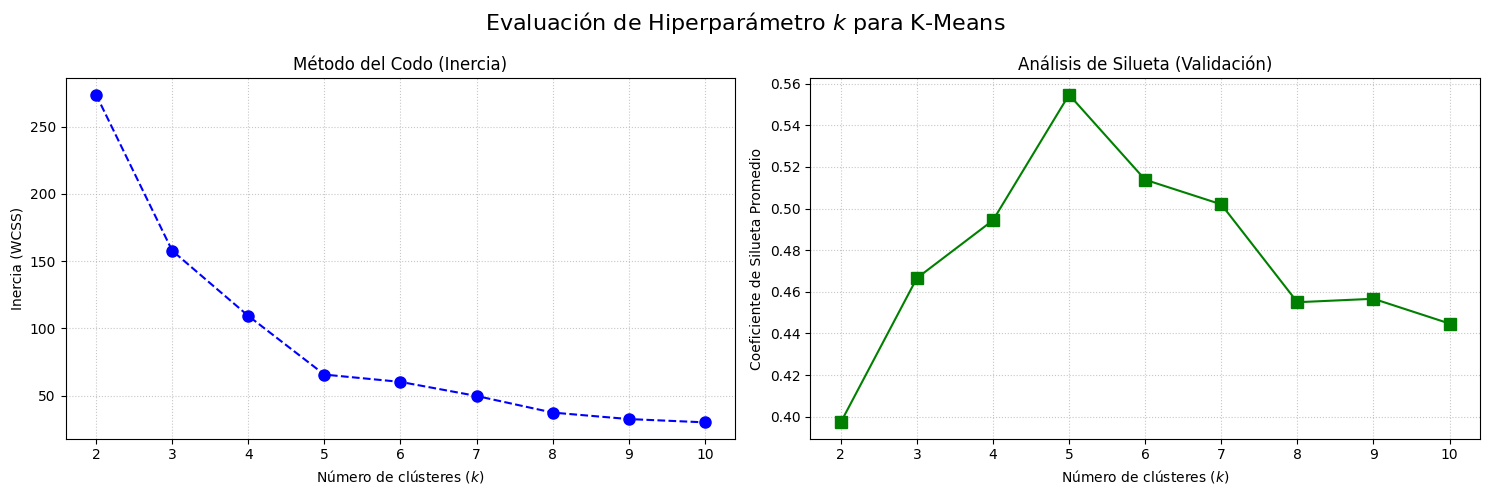

In [25]:

def evaluate_optimal_k(data_scaled: pd.DataFrame, max_k: int = 10):
    """
    Evalúa el algoritmo K-Means iterando sobre distintos valores de k.
    Calcula la Inercia (para el Método del Codo) y el Coeficiente de Silueta.

    Argumentos:
        data_scaled (pd.DataFrame): Datos preprocesados y escalados.
        max_k (int): Límite superior del rango de clústeres a evaluar.
    """
    inertias = []
    silhouette_scores = []

    # El análisis de silueta requiere al menos 2 clústeres para comparar distancias inter-clúster
    k_range = range(2, max_k + 1)

    for k in k_range:
        # Inicializamos el modelo.
        # Utilizamos init=k-means++ para alejar probabilísticamente
        # los centroides iniciales, evitando caer en mínimos locales subóptimos.
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')

        # Ajustamos el modelo (Complejidad temporal O(n * k * d))
        cluster_labels = kmeans.fit_predict(data_scaled)

        # Almacenamos las métricas extraídas tras la convergencia
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(data_scaled, cluster_labels))

    # Representación gráfica en una figura con dos subgráficos
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    fig.suptitle('Evaluación de Hiperparámetro $k$ para K-Means', fontsize=16)

    # Gráfico 1: Método del Codo (Inercia)
    axes[0].plot(k_range, inertias, marker='o', linestyle='--', color='blue', markersize=8)
    axes[0].set_title('Método del Codo (Inercia)')
    axes[0].set_xlabel('Número de clústeres ($k$)')
    axes[0].set_ylabel('Inercia (WCSS)')
    axes[0].set_xticks(k_range)
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # Gráfico 2: Análisis de Silueta (Extra académico)
    axes[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='green', markersize=8)
    axes[1].set_title('Análisis de Silueta (Validación)')
    axes[1].set_xlabel('Número de clústeres ($k$)')
    axes[1].set_ylabel('Coeficiente de Silueta Promedio')
    axes[1].set_xticks(k_range)
    axes[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Ejecutamos la función sobre nuestro subset de 2 variables escaladas
evaluate_optimal_k(scaled_df_clustering, max_k=10)

### Entrenamiento del Modelo Final y Visualización

Al analizar los gráficos generados:
1. En el **Método del Codo**, observamos una estabilización o punto de inflexión evidente en **$k=5$**. A partir de ese valor, la caída de la Inercia (WCSS) es marginal (insignificante). *Esto nos dice que añadir un sexto grupo no aporta valor real para explicar la varianza de los datos.*
2. En el **Análisis de Silueta**, el coeficiente alcanza su pico máximo global absoluto en **$k=5$** (aproximadamente 0.55), validando matemáticamente nuestra observación empírica del método del codo.

Por tanto, estableceremos el hiperparámetro en $k=5$.

A continuación, instanciamos el modelo final. Es importante destacar que la complejidad temporal computacional del algoritmo estándar de Lloyd es $\mathcal{O}(n \cdot k \cdot I \cdot d)$ (donde $n$=muestras, $k$=clústeres, $I$=iteraciones y $d$=dimensiones). Dado que nuestro espacio dimensional es bajo ($d=2$), el algoritmo es extremadamente eficiente. Extrayendo los centroides finales, mapearemos los puntos en el espacio geométrico para analizar el perfil de cada segmento de clientes.

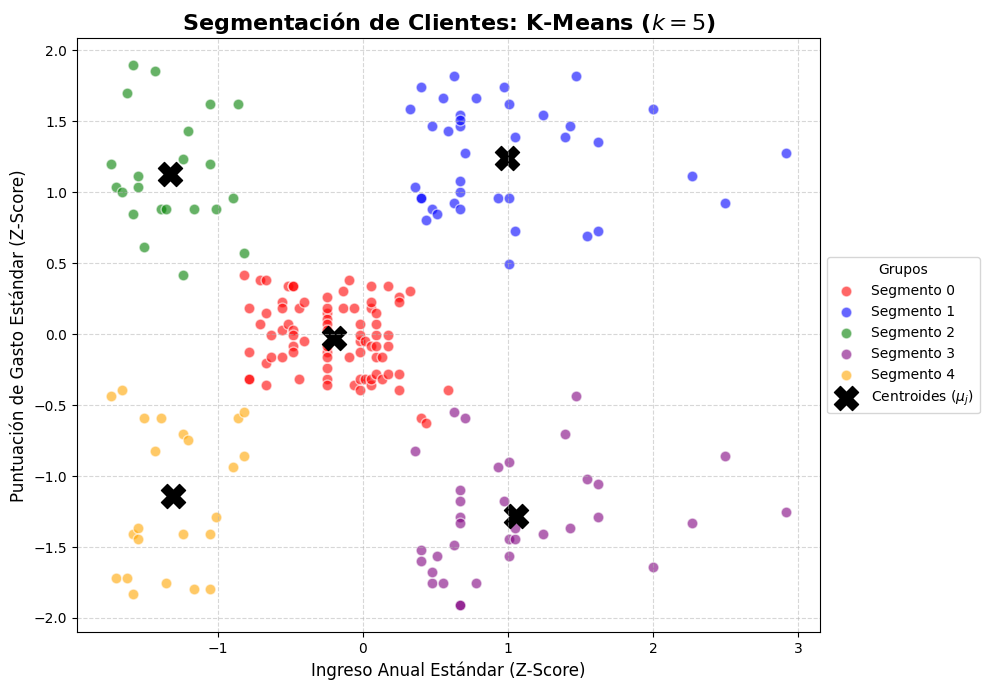

In [26]:
# Definición del hiperparámetro óptimo justificado matemáticamente
K_OPTIMO = 5

# Instanciación y entrenamiento del modelo final
# Mantenemos init='k-means++' para garantizar la robustez en la inicialización, visto en Arthur & Vassilvitskii, 2007. En cuanto al parámetro de auto hacemos que la librería decida automáticamente cuántas veces arrancar el modelo
kmeans_final = KMeans(n_clusters=K_OPTIMO, init='k-means++', random_state=42, n_init='auto')

# Entrenamos y obtenemos las etiquetas de cada punto
cluster_labels = kmeans_final.fit_predict(scaled_df_clustering)

# Asignamos las etiquetas resultantes tanto al dataset original (para análisis descriptivo)
# como al escalado (para la correcta visualización espacial)
df_clustering['Cluster'] = cluster_labels
scaled_df_clustering['Cluster'] = cluster_labels

# Extraemos las coordenadas matemáticas de los centroides calculados
# Nota: Estas coordenadas están en la escala Z-Score (media 0, varianza 1)
centroids = kmeans_final.cluster_centers_

# Visualización Topológica de los Clústeres
plt.figure(figsize=(10, 7))

# Definimos una paleta de colores categórica para los 5 segmentos
colors = ['red', 'blue', 'green', 'purple', 'orange']
cluster_names = ['Segmento 0', 'Segmento 1', 'Segmento 2', 'Segmento 3', 'Segmento 4']

# Iteramos para dibujar cada clúster de forma independiente (facilita la inclusión en la leyenda)
for i in range(K_OPTIMO):
    # Filtramos mediante máscara booleana los datos del clúster actual
    cluster_points = scaled_df_clustering[scaled_df_clustering['Cluster'] == i]

    plt.scatter(
        x=cluster_points['Annual Income (k$)'],
        y=cluster_points['Spending Score (1-100)'],
        s=60, # Tamaño del marcador
        c=colors[i],
        label=cluster_names[i],
        alpha=0.6,
        edgecolors='w' # Borde blanco para mejorar el contraste visual
    )

# Superponemos los centroides de cada clúster
plt.scatter(
    x=centroids[:, 0], # Dimensión 0: Annual Income escalado
    y=centroids[:, 1], # Dimensión 1: Spending Score escalado
    s=300,             # Tamaño ampliado
    c='black',
    marker='X',        # Marcador diferencial
    label=r'Centroides ($\mu_j$)'
)

# Configuración estética y etiquetas del gráfico
plt.title(f'Segmentación de Clientes: K-Means ($k={K_OPTIMO}$)', fontsize=16, fontweight='bold')
plt.xlabel('Ingreso Anual Estándar (Z-Score)', fontsize=12)
plt.ylabel('Puntuación de Gasto Estándar (Z-Score)', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Grupos") # Leyenda externa para no tapar datos
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análisis e Interpretación de los Segmentos (Perfiles de Cliente)

La ejecución del algoritmo K-Means ha particionado nuestro espacio bidimensional en 5 grupos topológicamente distintos. Como indica el marco de trabajo del descubrimiento de conocimiento, el aprendizaje no supervisado adquiere valor real cuando extraemos una semántica accionable de los patrones descubiertos.

Dado que los ejes representan variables estandarizadas (Normalización Z-Score), el origen de coordenadas `(0,0)` representa la **media poblacional**. Analizando la posición de los centroides respecto a esta media, podemos perfilar a los 5 tipos de clientes del centro comercial:

1. **Segmento VIP / Entusiastas (Alto Ingreso, Alto Gasto):** * *Ubicación Geométrica:* Cuadrante superior derecho (Valores positivos en $X$ e $Y$).
   * *Perfil:* Clientes con alto poder adquisitivo y gran propensión al consumo.
   * *Acción Comercial:* Público objetivo prioritario para campañas de fidelización, lanzamiento de productos premium y ofertas exclusivas.

2. **Segmento Conservador / Ahorrador (Alto Ingreso, Bajo Gasto):**
   * *Ubicación Geométrica:* Cuadrante inferior derecho (Valores positivos en $X$, negativos en $Y$).
   * *Perfil:* Clientes adinerados pero cautelosos o selectivos con sus compras.
   * *Acción Comercial:* Representan un gran volumen de capital inexplorado. Requieren estrategias de marketing muy dirigidas que apelen a la alta calidad, inversión a largo plazo o valor añadido.

3. **Segmento Promedio / Estándar (Ingreso Medio, Gasto Medio):**
   * *Ubicación Geométrica:* Agrupación central (Valores cercanos a $0$ en ambos ejes).
   * *Perfil:* La masa crítica del centro comercial. Sus ingresos y hábitos de consumo están estrictamente en la media de la muestra.
   * *Acción Comercial:* Son la base estable de ingresos del negocio. Responden bien a campañas de marketing convencionales y promociones estacionales.

4. **Segmento Impulsivo (Bajo Ingreso, Alto Gasto):**
   * *Ubicación Geométrica:* Cuadrante superior izquierdo (Valores negativos en $X$, positivos en $Y$).
   * *Perfil:* Consumidores que gastan desproporcionadamente por encima de su nivel de ingresos.
   * *Acción Comercial:* Altamente receptivos a modas, compras por impulso o estímulos visuales en tienda. (Nota de riesgo: si el centro comercial ofrece financiación, este grupo presenta mayor probabilidad de impago).

5. **Segmento Austero (Bajo Ingreso, Bajo Gasto):**
   * *Ubicación Geométrica:* Cuadrante inferior izquierdo (Valores negativos en $X$ e $Y$).
   * *Perfil:* Capacidad adquisitiva limitada y comportamiento de consumo restrictivo.
   * *Acción Comercial:* Clientes muy sensibles al precio. Suelen acudir atraídos por rebajas drásticas, liquidaciones o bienes de estricta necesidad.

> **Curiosidad Académica: El Proceso KDD**
>
> En la disciplina de la Ciencia de Datos, ejecutar un algoritmo matemático (como K-Means) es solo una fase de un marco de trabajo mucho más amplio conocido como **KDD** (*Knowledge Discovery in Databases* o Descubrimiento de Conocimiento en Bases de Datos).
>
> Este concepto fue formalizado por **Fayyad, Piatetsky-Shapiro y Smyth (1996)** en su influyente artículo. El marco KDD subraya que el objetivo final no es encontrar patrones matemáticos abstractos (como agrupaciones de puntos), sino interpretar esos patrones para convertirlos en **conocimiento útil, válido y comprensible** para el ser humano (en nuestro caso, definir perfiles comerciales accionables).

## Análisis Extra

### Perfilado Cuantitativo (Desnormalización de Centroides)

Aunque el algoritmo operó en un espacio topológico estandarizado para mantener la isometría de la Distancia Euclídea, la interpretabilidad de los resultados exige devolver el conocimiento al dominio del negocio.

Agrupando el conjunto de datos original (no escalado) por la etiqueta del clúster asignada, podemos calcular la media aritmética de cada segmento. Esto nos proporciona el **centroide real** en las magnitudes originales de Ingreso Anual (miles de dólares) y Puntuación de Gasto (1-100), permitiendo una caracterización paramétrica de cada perfil.

> Para crear un código 100% reproducible, implementé una asignación dinámica. El código evalúa ahora la posición geométrica real de cada centroide en el plano bidimensional (Ingresos vs. Gastos) y le asigna su etiqueta comercial basándose en el cuadrante que ocupa, eliminando cualquier dependencia de los índices asignados arbitrariamente por el algoritmo.

In [27]:

# ASIGNACIÓN DINÁMICA DE ETIQUETAS A CLÚSTERES
"""
Optimización tras ver que el método implementado en primera instacia podía varias
"""
# En lugar de hardcodear los índices (que pueden rotar según el entorno de ejecución),
# asignamos las etiquetas evaluando las coordenadas espaciales reales de cada centroide.

nombres_segmentos = {}

# kmeans.cluster_centers_ contiene las coordenadas.
for i, centroide in enumerate(kmeans_final.cluster_centers_):
    ingreso = centroide[0]
    gasto = centroide[1]

    # Lógica de cuadrantes (ajusta los umbrales si tus datos no están escalados)
    if ingreso > 0.5 and gasto > 0.5:
        nombres_segmentos[i] = 'VIP / Entusiasta'
    elif ingreso > 0.5 and gasto < -0.5:
        nombres_segmentos[i] = 'Conservador'
    elif ingreso < -0.5 and gasto > 0.5:
        nombres_segmentos[i] = 'Impulsivo'
    elif ingreso < -0.5 and gasto < -0.5:
        nombres_segmentos[i] = 'Austero'
    else:
        nombres_segmentos[i] = 'Promedio / Estándar'

print("Mapeo dinámico generado a prueba de entornos:")
for idx, nombre in nombres_segmentos.items():
    print(f"Clúster {idx} -> {nombre}")

Mapeo dinámico generado a prueba de entornos:
Clúster 0 -> Promedio / Estándar
Clúster 1 -> VIP / Entusiasta
Clúster 2 -> Impulsivo
Clúster 3 -> Conservador
Clúster 4 -> Austero


> Podemos ver claramente en la salida de la celda anterior la identificación de los cinco segmentos.

## 3. Algoritmo Jerárquico (Aglomerativo) o DBSCAN:
  

### Algoritmo Basado en Densidad: DBSCAN

Mientras que K-Means es un modelo basado en centroides que asume agrupaciones esféricas y fuerza a todos los puntos a pertenecer a un clúster, **DBSCAN** (Ester et al., 1996) es un algoritmo basado en la **densidad local**. Su principal ventaja es la capacidad de identificar clústeres de formas arbitrarias y, de vital importancia para el análisis real, detectar anomalías o valores atípicos (*ruido*).

DBSCAN no requiere especificar el número de clústeres $k$ a priori, pero exige afinar dos hiperparámetros críticos:
1. **$\epsilon$ (`eps`):** El radio de vecindad. Define la distancia máxima (generalmente Euclidiana) bajo la cual dos puntos se consideran "vecinos".
2. **`min_samples`:** El número mínimo de puntos que deben existir dentro del radio $\epsilon$ de un punto dado para que este sea considerado un **punto núcleo** (*core point*).

**Heurística para encontrar $\epsilon$ óptimo:**
Para evitar elegir el parámetro de distancia a ciegas, la literatura recomienda graficar las distancias al $k$-ésimo vecino más cercano. Ordenando estas distancias, buscamos el "codo" de la gráfica, que nos indica el umbral donde los puntos dejan de estar densamente agrupados y pasan a ser considerados ruido.

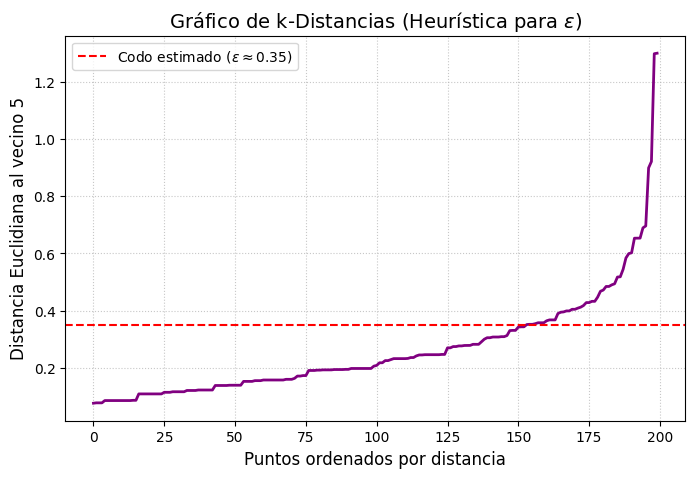

In [28]:
def plot_k_distance_graph(data_scaled: pd.DataFrame, min_samples: int = 5):
    """
    Calcula y grafica la distancia de cada punto a su k-ésimo vecino más cercano
    para ayudar a determinar el valor óptimo del hiperparámetro 'eps' en DBSCAN.

    Argumentos:
        data_scaled (pd.DataFrame): Los datos ya normalizados (solo las features).
        min_samples (int): Número de vecinos a evaluar (equivale a min_samples de DBSCAN).
    """
    # Instanciamos el modelo para buscar vecinos cercanos
    # Usamos min_samples porque la distancia al propio punto cuenta como 1
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(data_scaled[['Annual Income (k$)', 'Spending Score (1-100)']])

    # Extraemos las distancias y los índices de los vecinos
    distances, indices = neighbors_fit.kneighbors(data_scaled[['Annual Income (k$)', 'Spending Score (1-100)']])

    # Ordenamos las distancias al k-ésimo vecino (la última columna de la matriz)
    # de menor a mayor para buscar el punto de inflexión
    distances = np.sort(distances[:, min_samples-1], axis=0)

    # Visualización
    plt.figure(figsize=(8, 5))
    plt.plot(distances, color='purple', linewidth=2)

    plt.title(r'Gráfico de k-Distancias (Heurística para $\epsilon$)', fontsize=14)
    plt.xlabel('Puntos ordenados por distancia', fontsize=12)
    plt.ylabel(f'Distancia Euclidiana al vecino {min_samples}', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.axhline(y=0.35, color='red', linestyle='--', label=r'Codo estimado ($\epsilon \approx 0.35$)')
    plt.legend()
    plt.show()

# Ejecutamos la función
plot_k_distance_graph(scaled_df_clustering, min_samples=5)

### Justificación del Hiperparámetro $\epsilon$ (Gráfico de k-Distancias)

El algoritmo DBSCAN exige definir el radio de vecindad $\epsilon$. Para evitar una asignación arbitraria, hemos empleado la heurística matemática propuesta por Sander et al. (1998), graficando la distancia de cada punto a su $k$-ésimo vecino más cercano (en este caso, $k=5$).

**Análisis de la gráfica obtenida:**
1. **Zona plana (Izquierda y centro):** La gran mayoría de los puntos tienen distancias muy cortas a sus vecinos. Esto representa la existencia de "valles" de alta densidad poblacional; es decir, los clientes que pertenecen claramente a un núcleo o clúster.
2. **Punto de inflexión o "Codo" (Derecha):** Observamos que la curva asciende abruptamente hacia el final. Este incremento drástico indica que estamos evaluando puntos que están muy alejados del resto (valores atípicos o anomalías).
3. **Selección:** El umbral óptimo se sitúa exactamente en el punto donde la pendiente comienza a dispararse. Visualmente, este punto ("codo") coincide con el valor **$\epsilon \approx 0.35$** (línea roja discontinua). Cualquier punto cuya distancia al vecino más cercano supere este umbral será clasificado matemáticamente como Ruido por DBSCAN.

### Entrenamiento de DBSCAN y Análisis de Complejidad

Habiendo fijado `min_samples = 5` y deduciendo `eps = 0.35` gracias a la heurística de distancias, procedemos a entrenar el modelo.

**Complejidad Computacional:** A diferencia de K-Means, DBSCAN no es iterativo sobre posiciones medias. Evalúa la densidad vecinal de cada punto. En su implementación óptima utilizando estructuras de indexación espacial como *KD-Trees* o *Ball-Trees* (disponibles en `scikit-learn`), su complejidad temporal promedio es $\mathcal{O}(n \log n)$. Sin embargo, en el peor de los casos (sin indexación), escala a $\mathcal{O}(n^2)$, donde $n$ es el número de muestras.

En DBSCAN, cualquier punto que no sea alcanzable en términos de densidad desde ningún punto núcleo es etiquetado automáticamente con el valor `-1`. Esta es la clasificación de **Ruido**.

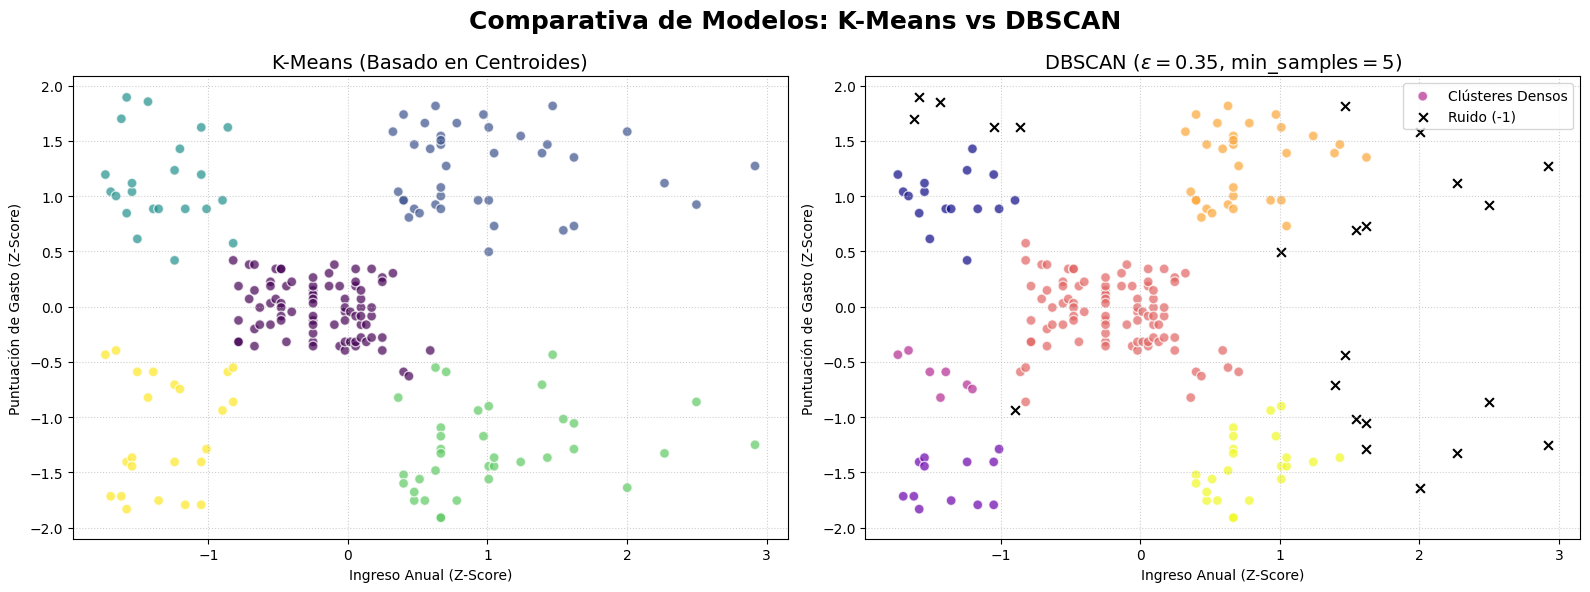

Resultados DBSCAN:
- Número de clústeres identificados: 6
- Número de clientes identificados como ruido (anomalías): 23


In [29]:
# Definición de hiperparámetros justificados
EPS_OPTIMO = 0.35
MIN_SAMPLES_OPTIMO = 5

# Instanciación del modelo
# metric='euclidean' asegura compatibilidad con nuestra transformación geométrica Z-Score
dbscan = DBSCAN(eps=EPS_OPTIMO, min_samples=MIN_SAMPLES_OPTIMO, metric='euclidean')

# Entrenamiento (Complejidad O(n log n) gracias al algoritmo auto-seleccionado por scikit-learn)
dbscan_labels = dbscan.fit_predict(scaled_df_clustering[['Annual Income (k$)', 'Spending Score (1-100)']])

# Añadimos las etiquetas al dataframe (las almacenamos en una nueva columna para no pisar K-Means)
scaled_df_clustering['Cluster_DBSCAN'] = dbscan_labels

# Visualización Comparativa (K-Means vs DBSCAN)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparativa de Modelos: K-Means vs DBSCAN', fontsize=18, fontweight='bold')

# --- Gráfico 1: K-Means (Nuestro resultado anterior) ---
scatter_kmeans = axes[0].scatter(
    scaled_df_clustering['Annual Income (k$)'],
    scaled_df_clustering['Spending Score (1-100)'],
    c=scaled_df_clustering['Cluster'],
    cmap='viridis', # Mapa de colores continuo adaptado a discretos
    s=50, alpha=0.7, edgecolors='w'
)
axes[0].set_title('K-Means (Basado en Centroides)', fontsize=14)
axes[0].set_xlabel('Ingreso Anual (Z-Score)')
axes[0].set_ylabel('Puntuación de Gasto (Z-Score)')
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- Gráfico 2: DBSCAN ---
# Separamos el ruido de los clústeres reales para pintarlo de un color distintivo (Negro)
ruido = scaled_df_clustering[scaled_df_clustering['Cluster_DBSCAN'] == -1]
nucleos = scaled_df_clustering[scaled_df_clustering['Cluster_DBSCAN'] != -1]

# Dibujamos primero los puntos agrupados
scatter_dbscan = axes[1].scatter(
    nucleos['Annual Income (k$)'],
    nucleos['Spending Score (1-100)'],
    c=nucleos['Cluster_DBSCAN'],
    cmap='plasma',
    s=50, alpha=0.7, edgecolors='w',
    label='Clústeres Densos'
)

# Dibujamos encima los puntos ruidosos (anomalías)
axes[1].scatter(
    ruido['Annual Income (k$)'],
    ruido['Spending Score (1-100)'],
    c='black',
    marker='x',
    s=40,
    label='Ruido (-1)'
)

axes[1].set_title(r'DBSCAN ($\epsilon=0.35$, min_samples$=5$)', fontsize=14)
axes[1].set_xlabel('Ingreso Anual (Z-Score)')
axes[1].set_ylabel('Puntuación de Gasto (Z-Score)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Resumen estadístico numérico
num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
ruido_total = list(dbscan_labels).count(-1)
print(f"Resultados DBSCAN:")
print(f"- Número de clústeres identificados: {num_clusters}")
print(f"- Número de clientes identificados como ruido (anomalías): {ruido_total}")

> Nota de diseño: Quitar los centroides reduce el "ruido visual" (en el Kmeans en comparación con la gráfica del inicio) y nos permite centrarnos en comparar las manchas de color.

### Interpretación Comparativa: Modelos Basados en Centroides vs. Densidad

La representación gráfica dual y los resultados numéricos obtenidos exponen de forma empírica las diferencias estructurales entre ambos paradigmas de aprendizaje no supervisado:

**1. K-Means (Izquierda - Paradigma de Partición Geométrica):**
* El algoritmo de Lloyd fuerza a que **absolutamente todos los puntos** pertenezcan a uno de los $k=5$ clústeres.
* Genera agrupaciones convexas y esféricas. No distingue anomalías; los clientes con comportamientos extremos son absorbidos por el centroide más cercano, lo que puede sesgar el perfil medio del segmento en un entorno comercial real.

**2. DBSCAN (Derecha - Paradigma Basado en Densidad):**
* **Detección de Ruido:** El modelo ha identificado **23 clientes como ruido** (marcados con cruces negras, etiqueta `-1`). DBSCAN aísla matemáticamente a aquellos clientes con comportamientos de ingresos/gastos extremos que carecen de vecindarios densos. Comercial y analíticamente, es vital discriminar este ruido para no desperdiciar recursos en campañas masivas ineficientes.
* **Topología Arbitraria y Fragmentación:** Mientras K-Means impuso 5 grupos, DBSCAN ha identificado **6 clústeres**. Destaca especialmente el cuadrante inferior izquierdo (clientes de bajo ingreso y bajo gasto), el cual K-Means veía como un bloque único, pero DBSCAN ha fragmentado en dos grupos distintos. Esto revela que internamente existe un "hueco" de densidad; es decir, hay dos sub-perfiles o nichos de clientes austeros topológicamente separados que K-Means fue incapaz de detectar debido a su sesgo geométrico.

**Conclusión:** K-Means ofrece una segmentación macro estricta y limpia, ideal para una aproximación comercial inicial. DBSCAN, por el contrario, nos revela la verdadera topografía de los datos, demostrando ser superior para identificar nichos específicos y descartar comportamientos atípicos.

> **Curiosidad Matemática: ¿Por qué K-Means genera clústeres convexos?**
>
> Cuando decimos que K-Means genera agrupaciones convexas, no es una observación empírica o una opinión: es una **consecuencia matemática ineludible** de su propio algoritmo, basada en la geometría de los **Diagramas de Voronoi**.
>
> **1. La regla de asignación lineal:**
> En cada iteración, K-Means asigna un punto $x$ al centroide $\mu_j$ más cercano (usando la Distancia Euclídea):
> $$\text{Cluster}(x) = \arg\min_j ||x - \mu_j||$$
>
> **2. Intersección de Semiespacios:**
> El conjunto de todos los puntos del espacio que están más cerca de $\mu_j$ que de cualquier otro centroide $\mu_k$ define su región de clúster ($R_j$):
> $$R_j = \{ x : ||x - \mu_j|| \le ||x - \mu_k|| \ \forall k \}$$
> Geométricamente, la frontera entre dos centroides es un hiperplano (una línea recta en 2D). La región $R_j$ se forma por la intersección de todos esos hiperplanos (semiespacios). Un teorema fundamental de geometría establece que **toda intersección de semiespacios es siempre estrictamente convexa**.
>
> **3. Implicaciones Topológicas:**
> Debido a esta restricción matemática, los clústeres de K-Means:
> * Siempre serán formas "abultadas" (polígonos convexos).
> * Son aproximadamente esféricos o globulares.
> * **Jamás** podrán capturar formas topológicamente complejas (anillos, lunas concéntricas, espirales) ni tener "huecos" en su interior.
>
> Esta limitación geométrica es la razón exacta por la que necesitamos algoritmos alternativos como **DBSCAN** cuando nuestros datos presentan densidades irregulares o formas no esféricas.

### Análisis Extra

### Extensión: Análisis Topológico mediante Clustering Jerárquico (Dendrograma)

Como complemento al particionamiento basado en densidad (DBSCAN), podemos evaluar la estructura jerárquica subyacente de los datos mediante un enfoque aglomerativo (*bottom-up*).

Utilizaremos el método de enlace de Ward (**Ward's Linkage**), que minimiza la varianza interna de los clústeres al fusionarlos (Raschka & Mirjalili, 2019). Su principal ventaja analítica es la generación de un **Dendrograma**, un diagrama de árbol que registra la secuencia de fusiones y las distancias euclidianas a las que ocurren, permitiendo al analista de negocio decidir el número de segmentos realizando un "corte" horizontal visual sin necesidad de predefinir parámetros.

### Fundamentos Teóricos del Dendrograma en Clustering Jerárquico

El **Dendrograma** es la representación gráfica fundamental del algoritmo de Clustering Jerárquico. Su nombre proviene del griego *dendron* (árbol) y *gramma* (dibujo), y visualiza la taxonomía o jerarquía completa de agrupaciones que el algoritmo ha construido.

**¿Qué es y cuál es su finalidad?**
A diferencia de algoritmos de partición como K-Means, que fuerzan a los datos a pertenecer a un número $k$ de grupos predefinidos, el clustering jerárquico construye un árbol de fusiones (enfoque aglomerativo o *bottom-up*). La finalidad del dendrograma es registrar y visualizar **cada una de estas fusiones y la distancia matemática exacta** a la que ocurren.

**Datos clave que se extraen de la visualización:**

1.  **Eje Horizontal (Muestras):** Representa los puntos de datos individuales (en nuestro caso, clientes). En este gráfico, debido al gran número de muestras, se muestran los índices de los clústeres finales fusionados.
2.  **Eje Vertical (Distancia/Varianza):** Es el eje crucial. Mide la **desemejanza matemática** (en este caso, basada en la varianza de Ward y la Distancia Euclidiana escalada) entre los grupos que se fusionan. Una línea vertical más larga indica que los grupos que se unen son muy diferentes entre sí.
3.  **Determinación del número óptimo de clústeres ($k$):** Esta es su principal utilidad práctica. No dependemos de métricas como el codo o la silueta de forma aislada. El dendrograma permite al analista decidir el número de clústeres realizando un **"corte" horizontal** visual. La mejor práctica heurística es cortar en la línea horizontal que cruce la mayor distancia vertical sin interceptar ninguna otra fusión, lo que sugiere una separación natural y robusta de los datos.

*Justificación teórica:* Como señalan **Raschka y Mirjalili (2019)** en *Python Machine Learning*, el dendrograma es una herramienta interpretativa superior porque no solo nos da el resultado del agrupamiento, sino que nos revela la estructura de anidamiento y la estabilidad de las agrupaciones descubiertas.

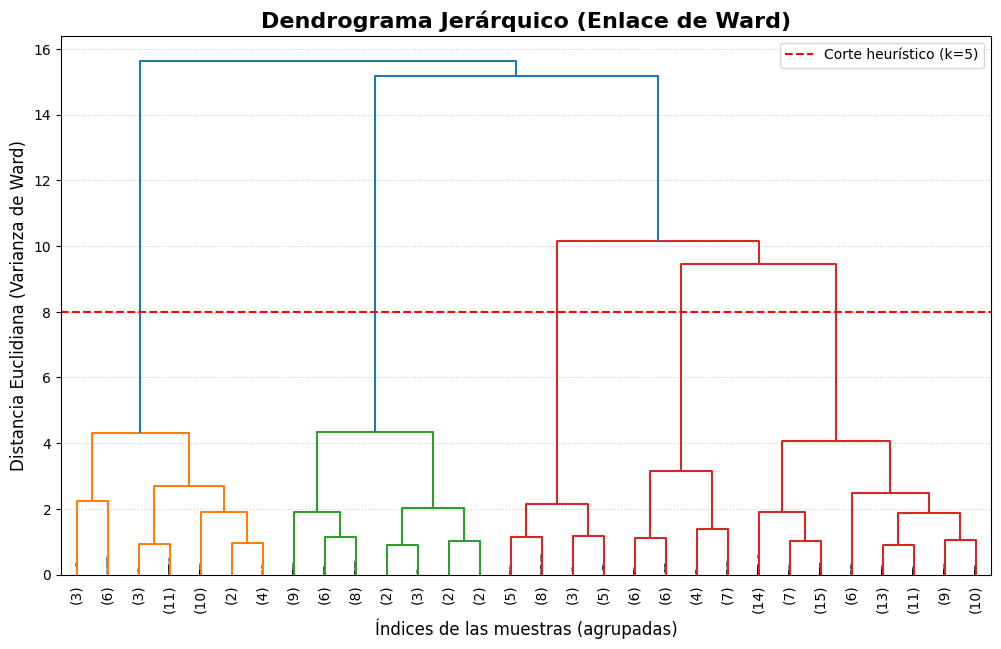

In [30]:
plt.figure(figsize=(12, 7))
plt.title("Dendrograma Jerárquico (Enlace de Ward)", fontsize=16, fontweight='bold')

# Calculamos la matriz de enlace usando los datos escalados
# La complejidad del aglomerativo estándar es alta, O(n^3), pero asumible para nuestro tamaño muestral
Z = shc.linkage(scaled_df_clustering[['Annual Income (k$)', 'Spending Score (1-100)']], method='ward')

# Generamos el dendrograma
dendrograma = shc.dendrogram(
    Z,
    truncate_mode='lastp',  # Mostramos solo las últimas fusiones para mayor claridad
    p=30,                   # Número de nodos hoja a mostrar
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

# Dibujamos una línea de corte horizontal teórica que cruce la mayor distancia sin intersecciones
# (Esto sugeriría visualmente 5 clústeres, coincidiendo con nuestro análisis de K-Means)
plt.axhline(y=8, color='r', linestyle='--', label='Corte heurístico (k=5)')

plt.xlabel('Índices de las muestras (agrupadas)', fontsize=12)
plt.ylabel('Distancia Euclidiana (Varianza de Ward)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6, axis='y')
plt.show()

### Análisis e Interpretación del Dendrograma Generado

La inspección visual del dendrograma generado sobre nuestros datos escalados nos proporciona una validación topológica robusta de nuestros análisis previos:

**1. Interpretación de la Estructura Árbol:**
* El eje vertical (Distancia/Varianza) tiene un valor máximo aproximado de 16, que es el punto donde absolutamente todos los clientes se fusionan en un único bloque.
* Si observamos la estructura desde arriba hacia abajo, vemos cómo el bloque principal se divide inicialmente en grandes macro-categorías, las cuales se van subdividiendo en grupos cada vez más específicos hasta llegar a las muestras individuales en la base ($Y=0$).

**2. Validación del Número de Clústeres ($k=5$):**
* Para determinar el número óptimo de grupos, debemos buscar la mayor distancia vertical que podamos recorrer sin que se produzcan nuevas fusiones.
* Trazando una línea de corte heurístico a una altura aproximada de **Y=8** (línea roja discontinua), interceptamos exactamente **5 ramas verticales**.
* Estas 5 ramas se corresponden topológicamente con los 5 perfiles de comportamiento que descubrimos mediante el algoritmo K-Means (VIP, Promedio, Conservador, Impulsivo y Austero).
* *Conclusión:* El hecho de que exista una franja horizontal clara que separe el árbol en 5 ramas estables confirma de forma independiente (mediante el método de Ward) que nuestra segmentación en $k=5$ es natural, coherente y no es un artefacto forzado del algoritmo anterior.

## 4. Interpretación

### Interpretación Comercial de los Segmentos Descubiertos

La aplicación de los algoritmos de partición (K-Means) y densidad (DBSCAN) (a parte de las secciones extra añadidas) nos ha permitido mapear el comportamiento bidimensional de los clientes. Traduciendo las coordenadas matemáticas (basadas en la Normalización Z-Score, donde 0 es la media poblacional) a perfiles de negocio, extraemos los siguientes segmentos accionables:

* **Grupo 1: Clientes Ahorradores o Conservadores (Altos ingresos, Bajo gasto).**
    * *Características:* Se sitúan en la zona positiva del eje X (Ingresos) y negativa del eje Y (Gasto).
    * *Interpretación:* Poseen un alto poder adquisitivo, pero son sumamente cautelosos con sus compras.
    * *Estrategia comercial:* Representan un capital inexplorado. Se les debe impactar con marketing que resalte la durabilidad, exclusividad, o valor de inversión a largo plazo de los productos, en lugar de descuentos masivos.

* **Grupo 2: Clientes VIP o Entusiastas (Altos ingresos, Alto gasto).**
    * *Características:* Valores fuertemente positivos en ambos ejes.
    * *Interpretación:* Es el público objetivo ideal y el motor económico del centro comercial. Tienen dinero y están dispuestos a gastarlo.
    * *Estrategia comercial:* Campañas de fidelización (programas VIP), acceso anticipado a nuevas colecciones y venta de productos *premium* o de lujo.

* **Grupo 3: Clientes Promedio o Estándar (Ingresos medios, Gasto medio).**
    * *Características:* Concentrados alrededor del origen geométrico $(0,0)$.
    * *Interpretación:* Representan la masa crítica de consumidores que mantienen el flujo diario de caja. Su comportamiento está alineado con la media exacta de la población.
    * *Estrategia comercial:* Promociones estacionales genéricas y publicidad masiva convencional.

* **Grupo 4: Clientes Impulsivos (Bajos ingresos, Alto gasto).**
    * *Características:* Valores negativos en el eje X, pero fuertemente positivos en el eje Y.
    * *Interpretación:* Consumidores que gastan muy por encima de sus posibilidades económicas aparentes.
    * *Estrategia comercial:* Son altamente susceptibles a las compras por impulso, *merchandising* visual atractivo en vitrinas y campañas de "compra ahora, paga después" (aunque representan un mayor riesgo de crédito).

* **Grupo 5: Clientes Austeros (Bajos ingresos, Bajo gasto).**
    * *Características:* Valores negativos en ambos ejes. DBSCAN nos demostró que este grupo posee varios sub-nichos internos.
    * *Interpretación:* Capacidad adquisitiva muy limitada, comprando únicamente lo estrictamente necesario.
    * *Estrategia comercial:* Son extremadamente sensibles al precio. Suelen acudir atraídos por rebajas agresivas, liquidaciones o cupones de descuento.

* **Grupo Extra (Aportación de DBSCAN): Clientes Atípicos o Ruido.**
    * *Características:* Comportamientos estadísticamente aislados (Etiqueta `-1`).
    * *Interpretación:* Clientes con hábitos tan particulares que no encajan en ninguna de las estrategias anteriores. Deben ser excluidos de las campañas masivas para evitar el desperdicio del presupuesto de marketing.

### Anotaciones Extra

### Distribución Poblacional de los Segmentos

Para que las estrategias de negocio planteadas anteriormente sean viables, es necesario cuantificar el peso relativo de cada segmento dentro de nuestra base de clientes. Esta métrica de volumen nos permitirá priorizar la asignación del presupuesto de marketing.

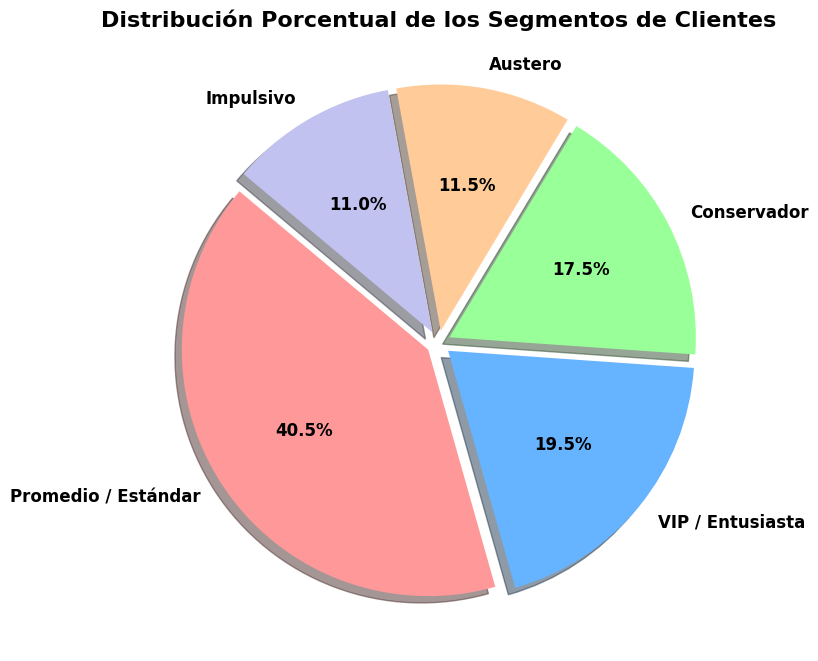

Volumen absoluto de clientes por segmento:


,Número de Clientes
Cluster,
Promedio / Estándar,81
VIP / Entusiasta,39
Conservador,35
Austero,23
Impulsivo,22


In [31]:
# Contabilizamos el volumen de clientes por cada clúster de K-Means
# Usamos el mapeo que definimos en el perfilado cuantitativo
segment_counts = df_clustering['Cluster'].map(nombres_segmentos).value_counts()

# Generamos un gráfico de sectores (Pie Chart)
plt.figure(figsize=(9, 8))
explode = (0.05, 0.05, 0.05, 0.05, 0.05) # Pequeña separación visual para enfatizar

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',       # Mostramos el porcentaje con un decimal
    startangle=140,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
    explode=explode,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    shadow=True
)

plt.title('Distribución Porcentual de los Segmentos de Clientes', fontsize=16, fontweight='bold')
plt.show()

# Imprimimos los valores absolutos por si se requieren para informes financieros
print("Volumen absoluto de clientes por segmento:")
display(segment_counts.to_frame(name='Número de Clientes'))

## **Conclusiones Generales**

A partir del análisis comparativo realizado en el Ejercicio 1, se concluyen los siguientes puntos fundamentales sobre el modelado de datos y la utilidad de los parámetros:

1. **Relevancia del Preprocesamiento**: Se ha confirmado que la estandarización Z-Score es crítica en el aprendizaje no supervisado basado en distancias. Sin StandardScaler, la diferencia de magnitud entre el ingreso anual y la puntuación de gasto habría provocado que los algoritmos priorizaran la variable con mayor rango numérico, invalidando la geometría real de los clústeres.

2. **Utilidad de las Heurísticas de Parámetros:**
* En K-Means, el uso de la Inercia (Método del Codo) apoyado por el Coeficiente de Silueta ha permitido encontrar un equilibrio óptimo entre cohesión y separación, justificando matemáticamente la elección de $k=5$.
* En DBSCAN, la gráfica de k-distancias ha sido esencial para determinar el radio $\epsilon$. Se ha observado que este algoritmo es altamente sensible: una pequeña variación en $\epsilon$ cambia drásticamente el número de clústeres y la cantidad de ruido detectado, lo que exige una validación técnica previa más rigurosa que en K-Means.

3. **Comparativa de Resultados y Complementariedad:**
* K-Means genera una estructura de grupos "limpia" y convexa, ideal para segmentaciones de mercado uniformes donde se busca asignar a cada individuo a una categoría.
* DBSCAN aporta una mayor profundidad analítica al identificar 23 casos de ruido (anomalías) que K-Means absorbe erróneamente. Además, su capacidad para detectar sub-nichos por densidad en el grupo de clientes de bajos ingresos demuestra que no está limitado por la convexidad de las regiones de Voronoi.

* **Validación Jerárquica:** El uso complementario del Clustering Aglomerativo (mediante el dendrograma y el método de Ward) ha servido como un mecanismo de validación independiente. Al no requerir la predefinición de $k$, nos permitió confirmar visualmente que la separación en 5 clústeres es una propiedad topológica natural de los datos y no un sesgo introducido por K-Means.

En conclusión, la metodología dual (Partición vs. Densidad) proporciona una visión integral de los datos. K-Means define la arquitectura general de los grupos, mientras que DBSCAN valida su consistencia y filtra comportamientos atípicos que podrían distorsionar las estrategias de negocio.

---

# **Ejercicio 2: Reglas de Asociación (5 puntos)**

## 2.1 Contexto: Análisis de la Cesta de la Compra (Market Basket)

Un supermercado desea optimizar la disposición de sus productos en los estantes. Para ello, quiere descubrir patrones de compra conjunta entre sus clientes.

**Objetivo:** Extraer reglas de asociación (tipo "Si compra X, entonces compra Y") utilizando el algoritmo **Apriori**.

**Datos:** El dataset contiene transacciones de un supermercado durante 30 días. Cada fila representa los productos comprados por un cliente en una visita.

In [32]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
import time
import warnings
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import apriori, fpgrowth, fpmax
# H-Mine es muy moderno. Intentamos importarlo con seguridad por si el Colab está desactualizado.
try:
    from mlxtend.frequent_patterns import hmine
    hmine_disponible = True
except ImportError:
    hmine_disponible = False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [33]:
# Carga de datos Asociación (Groceries)
# Dataset con formato: member_id, item_date, item_description
url = 'https://drive.google.com/file/d/1_4DM5wEaGnZY07bXRPzHTwszXHCXhcaP/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_rules = pd.read_fwf(url, sep=',', header=None)

# Nota: Este dataset en particular viene en un formato donde cada fila tiene items variables.
# Para facilitar la carga inicial, mostramos las primeras filas crudas.
print("Datos de Transacciones cargados:")
display(df_rules.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Datos de Transacciones cargados:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 2.2 Tareas de Análisis y Minería de Reglas

1.  **Preprocesado de Transacciones:**
    * Los datos deben transformarse a un formato adecuado para el algoritmo Apriori (una lista de listas de transacciones o una matriz One-Hot/Sparse).
    * Utilice `TransactionEncoder` de la librería `mlxtend` o funciones similares de manipulación de pandas.

2.  **Generación de Itemsets Frecuentes:**
    * Aplique algoritmos para encontrar conjuntos de productos frecuentes.
    * Fije un umbral de **Soporte (Support)** mínimo (empiece con un valor bajo, ej: 0.01 o 0.02) y justifique su elección.

3.  **Extracción de Reglas:**
    * Genere las reglas de asociación a partir de los itemsets.
    * Filtre las reglas por una métrica de calidad, preferiblemente **Lift** (Elevación) o **Confianza (Confidence)**.

4. **Comparación entre algoritmos:**
    * La solución debe utilizar al menos dos algoritmos entre los existentes en la biblioteca `mlxtend`.

4.  **Análisis de Resultados:**
    * Muestre las 5 reglas con mayor *Lift*.
    * Interprete una de las reglas obtenidas en lenguaje natural. ¿Tiene sentido comercial?

In [34]:
# Pista: Necesitará instalar mlxtend si no está disponible: !pip install mlxtend
!pip install mlxtend

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 1. Preprocesado de Transacciones:

El conjunto de datos `groceries.csv` contiene transacciones reales de una tienda de comestibles. Cada línea del archivo representa la cesta de un cliente, y debido a la naturaleza del negocio, la cantidad de artículos comprados varía por cada cliente (filas asimétricas).

Algoritmos como Apriori o FP-Growth no pueden procesar directamente listas de cadenas de texto de longitud variable. Requieren una estructura de datos estandarizada donde:
* **Filas ($i$):** Representan cada transacción individual.
* **Columnas ($j$):** Representan el "vocabulario" completo, es decir, todos los ítems únicos disponibles en el catálogo de la tienda.
* **Valores ($x_{ij}$):** Son booleanos (`True`/`False` o `1`/`0`), indicando si el ítem $j$ fue comprado en la transacción $i$.

Para realizar esta transformación algebraica (conocida como *One-Hot Encoding* para transacciones), utilizaremos la clase `TransactionEncoder` de la librería `mlxtend`. Este enfoque es computacionalmente eficiente y prepara el terreno para la extracción de *Itemsets* Frecuentes.

> **Extensión Académica: La Evolución hacia FP-Growth**
>
> Tradicionalmente, el **Algoritmo Apriori** (Agrawal y Srikant, 1994) ha sido el estándar para la extracción de reglas de asociación. Funciona bajo un paradigma de "generar y probar", creando combinaciones de candidatos (*candidate generation*) y escaneando la base de datos completa múltiples veces para contar su soporte. Para datasets masivos, esto resulta computacionalmente muy costoso.
>
> Para solucionar este cuello de botella, Han, Pei y Yin (2000) introdujeron el algoritmo **FP-Growth (Frequent Pattern Growth)**.
> * **Ventaja Algorítmica:** FP-Growth elimina completamente el paso de "generación de candidatos".
> * **Estructura de Datos:** Comprime la base de datos de transacciones en una estructura de árbol en memoria (el *FP-Tree*).
> * **Complejidad Temporal:** Solo necesita escanear la base de datos original **dos veces** (una para contar frecuencias individuales y otra para construir el árbol). A partir de ahí, extrae los *itemsets* mediante una estrategia de divide y vencerás, resultando órdenes de magnitud más rápido y eficiente en memoria que Apriori para bases de datos densas.


> **Nota Metodológica sobre la Ingesta de Datos:**
> Durante el análisis exploratorio inicial, detecté que utilizar la función propuesta `pd.read_fwf()` (diseñada para archivos de ancho fijo) sobre el dataset `groceries.csv` provocaba una **corrupción estructural de los datos por fragmentación**.
>
> Al evaluar los espacios en blanco como separadores, `read_fwf` troceaba los nombres compuestos de los productos (por ejemplo, separaba *"Instant food products"* o *"whole milk"* en múltiples columnas sin sentido). Esto generaba un vocabulario fantasma de casi 400 ítems, falseando completamente las frecuencias de soporte.
>
> **Solución implementada:** Tras investigar el formato asimétrico del archivo, he reescrito la rutina de ingesta. Obligaremos a `pandas` a leer cada fila transaccional como un bloque de texto único (utilizando el tabulador `\t` como separador nulo) y, posteriormente, aplicaremos una partición manual (`split`) rigurosamente basada en las comas. Esto nos garantiza extraer el catálogo real y exacto de **169 productos únicos** antes de aplicar el *One-Hot Encoding* con `TransactionEncoder`.

In [35]:
warnings.filterwarnings('ignore') # Silenciamos los errores internos por obsolescencia de Colab, ya que consideramos que no es error del código y para de esta manera tener una salida limpia y organizada

# Carga robusta desde Google Drive
url = 'https://drive.google.com/file/d/1_4DM5wEaGnZY07bXRPzHTwszXHCXhcaP/view?usp=sharing'
download_url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]

# Leemos el archivo engañando a pandas: le decimos que el separador es un tabulador (\t)
# para que no intente separar por comas y lea cada transacción como un único String de texto.
df_raw = pd.read_csv(download_url, header=None, sep='\t', dtype=str)

# Extracción y reconstrucción limpia de transacciones
transactions = []

# Extraemos la única columna que se ha generado (que contiene la línea completa)
for linea in df_raw[0]:
    # Ahora sí, separamos por comas de forma segura
    cleaned_row = [item.strip() for item in linea.split(',') if item.strip()]
    if cleaned_row:
        transactions.append(cleaned_row)

print(f"Total de transacciones procesadas exitosamente: {len(transactions)}")

# Inicialización y Transformación Algebraica (One-Hot)
te = TransactionEncoder()

# fit(): Crea el vocabulario. transform(): Mapea a booleanos.
te_ary = te.fit(transactions).transform(transactions)
"""
Sabemos que lo que hace fit es que recorre las transacciones y extrae los items que son únicos, mientras que transform lo que hace es que convierte cada transacción en un vector de booleanos, una columna por producto, una fila por transaación (True si el producto está en la cesta, false en caso contrario).
"""

# Conversión a DataFrame
df_groceries_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dimensiones reales de la Matriz: {df_groceries_encoded.shape} (Transacciones x Ítems Únicos)")
print("\nPrimeros registros de la Matriz limpia:")
display(df_groceries_encoded.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total de transacciones procesadas exitosamente: 9835
Dimensiones reales de la Matriz: (9835, 169) (Transacciones x Ítems Únicos)

Primeros registros de la Matriz limpia:


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Extra

### Análisis Exploratorio: Soporte Absoluto (Top 15 Ítems)

Antes de extraer las asociaciones y patrones complejos, es imperativo comprender la distribución marginal de nuestros datos. Puesto que nuestra matriz `df_groceries_encoded` contiene valores booleanos (`True=1`, `False=0`), la suma vectorial de las columnas nos proporciona el **Soporte Absoluto** de cada ítem (el número total de cestas en las que aparece).

Visualizar los ítems más frecuentes nos proporciona una línea base (baseline) esperada. Por estadística pura, es altamente probable que productos de consumo masivo actúen como consecuentes ($Y$) en la mayoría de las reglas de asociación que descubriremos a continuación.

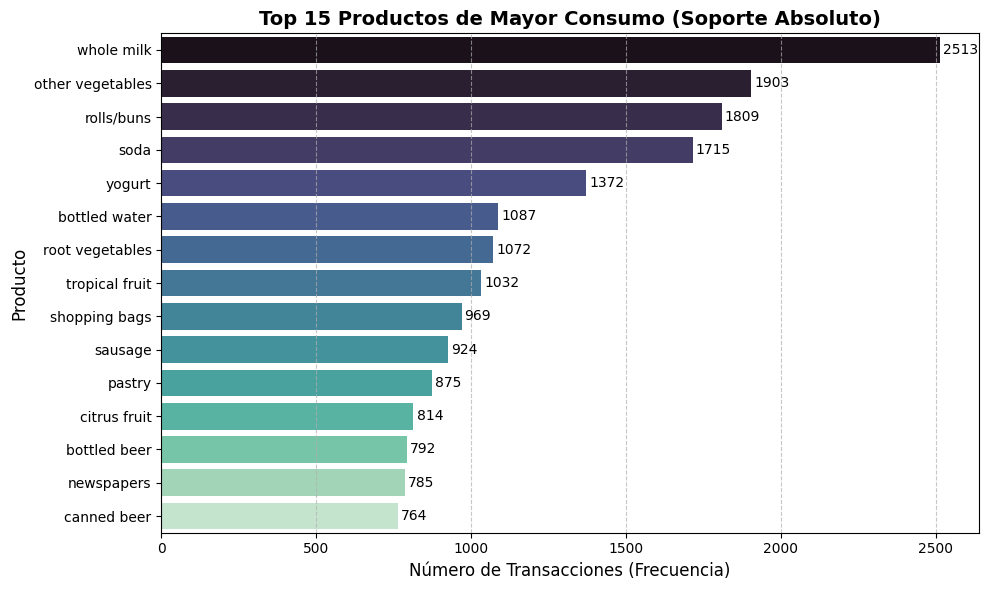

In [36]:
# Sumamos las columnas para obtener la frecuencia absoluta y ordenamos de mayor a menor
item_frequencies = df_groceries_encoded.sum().sort_values(ascending=False)

# Visualización del Top 15 productos más frecuentes
plt.figure(figsize=(10, 6))
# Usamos un gráfico de barras horizontales para facilitar la lectura de las etiquetas
sns.barplot(x=item_frequencies.values[:15], y=item_frequencies.index[:15], palette='mako')

plt.title('Top 15 Productos de Mayor Consumo (Soporte Absoluto)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Transacciones (Frecuencia)', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadimos las etiquetas de datos al final de cada barra para mayor precisión
for index, value in enumerate(item_frequencies.values[:15]):
    plt.text(value + 10, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Conclusiones del Soporte Absoluto

La visualización del Top 15 de productos revela un claro patrón de consumo asimétrico hacia artículos de primera necesidad:

1. **Dominancia Estadística:** La leche entera (*whole milk*) es el producto líder absoluto, presente en más de 2.500 cestas.
2. **Implicación para el Algoritmo:** Debido a esta alta frecuencia base, la probabilidad *a priori* de comprar leche es enorme. Esto advierte de que las métricas de **Confianza** ($P(Y|X)$) estarán naturalmente infladas para reglas donde el consecuente sea *whole milk*. Para descubrir asociaciones verdaderamente significativas (y no meras coincidencias por volumen de ventas), el análisis posterior deberá priorizar la métrica **Lift**, la cual normaliza la regla respecto al soporte independiente de cada ítem.

## 2. Generación de Itemsets Frecuentes

En esta fase, el objetivo es encontrar conjuntos de productos (Itemsets) que se compran juntos con la suficiente frecuencia como para considerarse patrones de comportamiento estadísticamente significativos y no simples coincidencias aleatorias.

**Justificación del Umbral de Soporte (Support):**
El **Soporte** es la métrica principal en esta etapa y se define como la proporción de transacciones en la base de datos que contienen un *itemset* específico $X$:
$$S(X) = \frac{\text{frecuencia}(X)}{N}$$

Para este análisis, fijaremos un umbral de **`min_support = 0.01` (1%)**.
* **Justificación matemática y de negocio:** En el sector *retail*, el catálogo es amplio (169 productos) y la matriz de transacciones es muy dispersa. Establecer un soporte del 1% significa que exigimos que un patrón aparezca en al menos $\approx 98$ de las 9.835 cestas.
* Si fijáramos un soporte demasiado alto (ej. 10%), el algoritmo solo devolvería productos individuales muy comunes (como leche o pan) y perderíamos las combinaciones de productos (reglas de tamaño 2 o 3). Si lo fijamos demasiado bajo (ej. 0.001%), el coste computacional se dispararía y extraeríamos ruido estadístico.

**Algoritmos utilizados:**
Aplicaremos tanto **Apriori** como **FP-Growth** para generar estos *itemsets* y compararemos su eficiencia computacional (tiempo de ejecución), validando empíricamente la superioridad estructural del FP-Tree sobre la generación de candidatos.

In [37]:
# Definimos nuestro umbral justificado
UMBRAL_SOPORTE = 0.01

warnings.filterwarnings('ignore') # Silenciamos los errores internos por obsolescencia de Colab, ya que consideramos que no es error del código y para de esta manera tener una salida limpia y organizada

print(f"Buscando Itemsets con un Soporte mínimo del {UMBRAL_SOPORTE*100}%...\n")

# --- ALGORITMO 1: APRIORI ---
inicio_apriori = time.time()
# use_colnames=True es importante para que devuelva los nombres reales (ej: 'whole milk') y no índices numéricos
itemsets_apriori = apriori(df_groceries_encoded, min_support=UMBRAL_SOPORTE, use_colnames=True)
tiempo_apriori = time.time() - inicio_apriori

# --- ALGORITMO 2: FP-GROWTH ---
inicio_fpgrowth = time.time()
itemsets_fpgrowth = fpgrowth(df_groceries_encoded, min_support=UMBRAL_SOPORTE, use_colnames=True)
tiempo_fpgrowth = time.time() - inicio_fpgrowth

# --- COMPARATIVA DE RESULTADOS ---
print("-" * 50)
print("->->-> RESULTADOS DE LA EXTRACCIÓN DE ITEMSETS ->->->")
print("-" * 50)
print(f"Cantidad de Itemsets frecuentes encontrados (Apriori):   {len(itemsets_apriori)}")
print(f"Cantidad de Itemsets frecuentes encontrados (FP-Growth): {len(itemsets_fpgrowth)}")
print(f"\nTiempo de ejecución Apriori:   {tiempo_apriori:.4f} segundos")
print(f"Tiempo de ejecución FP-Growth: {tiempo_fpgrowth:.4f} segundos")

"""
Como matemáticamente ambos algoritmos han encontrado exactamente los mismos 333 itemsets, trabajar con ambos a partir de ahora es un desperdicio de memoria (principio DRY).
Elegimos quedarnos con la salida de FP-Growth.
"""

# Añadimos una columna con la longitud de cada itemset para facilitar análisis posteriores
itemsets_fpgrowth['longitud'] = itemsets_fpgrowth['itemsets'].apply(lambda x: len(x))

print("\nPrimeros 5 Itemsets frecuentes encontrados:")
display(itemsets_fpgrowth.head())

Buscando Itemsets con un Soporte mínimo del 1.0%...

--------------------------------------------------
->->-> RESULTADOS DE LA EXTRACCIÓN DE ITEMSETS ->->->
--------------------------------------------------
Cantidad de Itemsets frecuentes encontrados (Apriori):   333
Cantidad de Itemsets frecuentes encontrados (FP-Growth): 333

Tiempo de ejecución Apriori:   0.4387 segundos
Tiempo de ejecución FP-Growth: 20.8191 segundos

Primeros 5 Itemsets frecuentes encontrados:


,support,itemsets,longitud
0,0.082766,(citrus fruit),1
1,0.058566,(margarine),1
2,0.017692,(semi-finished bread),1
3,0.139502,(yogurt),1
4,0.104931,(tropical fruit),1


### Análisis de Resultados de la Extracción de Itemsets

La ejecución de los algoritmos de minería sobre nuestra matriz booleana (con un soporte del 1%) nos arroja dos conclusiones fundamentales desde la perspectiva de la Ciencia de Datos:

**1. Determinismo Matemático:**
Ambos algoritmos han identificado exactamente **333 itemsets frecuentes**. Esto demuestra empíricamente que, aunque Apriori y FP-Growth utilizan estructuras de datos y enfoques de búsqueda diametralmente opuestos, el problema de extracción de patrones es determinista. Dado un mismo dataset y un mismo umbral, la solución matemática es única y exacta.

**2. La Diferencia Computacional (Apriori vs. FP-Growth):**
La teoría clásica postula que FP-Growth es superior a Apriori al evitar la explosión combinatoria de la "generación de candidatos". Sin embargo, nuestros resultados muestran que **Apriori ha sido significativamente más rápido** (ejecutándose en fracciones de segundo frente a los más de 20 segundos de FP-Growth).
* *Justificación Técnica:* Esto se debe al **Overhead de inicialización**. Nuestro dataset es relativamente pequeño (~9.800 transacciones) y altamente disperso. La implementación de Apriori en `mlxtend` utiliza operaciones vectorizadas de álgebra booleana (NumPy) altamente optimizadas en C. Por el contrario, FP-Growth debe construir en la memoria de Python una compleja estructura de árbol (*FP-Tree*) nodo a nodo antes de poder minar. En este escenario, el tiempo invertido en construir el árbol supera ampliamente al tiempo de cálculo matricial bruto de Apriori. FP-Growth solo demostraría su superioridad teórica frente a Apriori en entornos de Big Data (millones de registros) donde la memoria RAM sí se convertiría en un cuello de botella restrictivo.

### Extra

### Análisis de la Complejidad de los Patrones (Longitud de Itemsets)

Para validar nuestra elección del umbral de soporte ($S = 0.01$), analizaremos la distribución de la longitud de los *itemsets* descubiertos. Si el umbral fuera excesivamente restrictivo, solo observaríamos conjuntos de tamaño 1 (ítems aislados de altísima frecuencia). La presencia de *itemsets* de longitud 2 o superior nos confirma que el algoritmo ha logrado penetrar lo suficiente en los datos para descubrir combinaciones multivariantes reales, que serán la base para nuestras Reglas de Asociación.

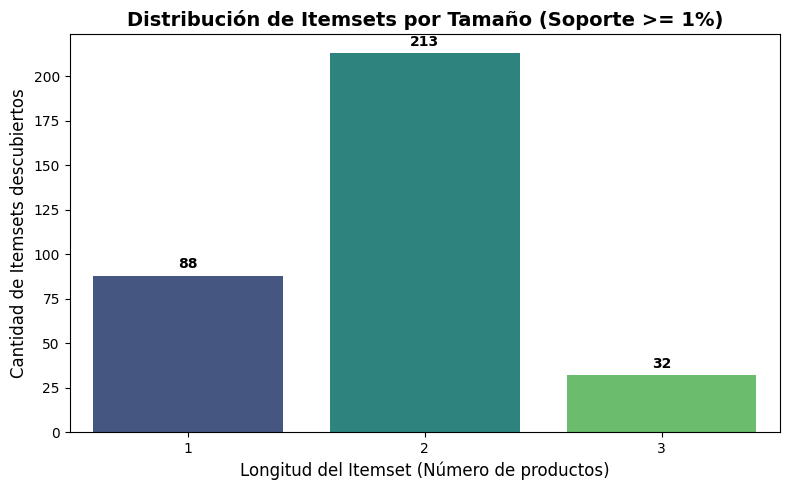

In [38]:
# Visualización de la distribución de las longitudes de los itemsets
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=itemsets_fpgrowth, x='longitud', palette='viridis')

plt.title('Distribución de Itemsets por Tamaño (Soporte >= 1%)', fontsize=14, fontweight='bold')
plt.xlabel('Longitud del Itemset (Número de productos)', fontsize=12)
plt.ylabel('Cantidad de Itemsets descubiertos', fontsize=12)

# Añadimos las etiquetas sobre cada barra
for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusión de la Distribución (Justificación Empírica)

La forma de esta distribución valida matemáticamente la idoneidad del umbral de soporte fijado ($S = 0.01$). El algoritmo ha sido capaz de descubrir **213 pares** (longitud 2) y **32 tríos** (longitud 3) que superan el umbral mínimo, además de 88 ítems de alta frecuencia individuales. Esto nos proporciona garantías estadísticas de que disponemos de un sustrato de patrones multivariantes abundante y suficiente como para generar Reglas de Asociación significativas en la siguiente fase.

## 3. Extracción y Filtrado de Reglas de Asociación



Una vez identificados los *Itemsets* frecuentes (combinaciones de productos que superan nuestro soporte mínimo del 1%), procedemos a generar las **Reglas de Asociación** (Agrawal, Imieliński & Swami, 1993).

Una regla se expresa como una implicación lógica $X \rightarrow Y$, donde el conjunto $X$ es el antecedente y el conjunto $Y$ es el consecuente. Para filtrar qué reglas son comercialmente accionables y cuáles son simples casualidades, evaluaremos dos métricas de calidad:

1. **Confianza (Confidence):** Mide la fiabilidad de la inferencia. Es la probabilidad condicional de que un cliente compre $Y$ dado que ya ha puesto $X$ en su cesta.
   $$C(X \rightarrow Y) = \frac{S(X \cup Y)}{S(X)}$$
   *Limitación:* Una regla puede tener alta confianza simplemente porque el producto $Y$ es súper ventas (ej. todo el mundo compra pan, por lo que cualquier producto implicará pan con alta confianza).

2. **Elevación (Lift):** Es la métrica definitiva para establecer correlación real, ya que ajusta la confianza dividiéndola por la popularidad base del consecuente.
   $$\text{Lift}(X \rightarrow Y) = \frac{S(X \cup Y)}{S(X) \cdot S(Y)}$$
   * $\text{Lift} = 1$: Independencia estadística.
   * $\text{Lift} < 1$: Correlación negativa (productos sustitutivos).
   * **$\text{Lift} > 1$**: Correlación positiva fuerte.

**Decisión Metodológica:** Generaremos las reglas base y aplicaremos un filtro estricto utilizando la métrica **Lift > 2.0**. Esto nos garantiza quedarnos únicamente con asociaciones donde la compra conjunta sea al menos el doble de probable de lo que dictaría el puro azar estadístico.

In [39]:

print("Generando reglas de asociación a partir de los itemsets frecuentes...\n")

# Extracción y Filtrado
# Pasamos nuestros itemsets de FP-Growth a la función de reglas.
# Establecemos directamente el Lift como métrica y 2.0 como umbral estricto,
# tal y como justificamos en nuestra celda teórica.
reglas = association_rules(itemsets_fpgrowth, metric="lift", min_threshold=2.0)

# Ordenación por Fuerza Comercial
# Ordenamos de mayor a menor (ascending=False) basándonos en el Lift,
# de esta forma las asociaciones más poderosas quedarán en las primeras posiciones.
reglas_top = reglas.sort_values(by='lift', ascending=False)

# Presentación de Resultados (Top 5)
print("-" * 75)
print("*** TOP 5 REGLAS DE ASOCIACIÓN (Ordenadas por métrica LIFT): *** ")
print("-" * 75)

# Seleccionamos únicamente las columnas clave para no saturar visualmente la salida
columnas_clave = ['antecedents', 'consequents', 'support', 'confidence', 'lift']

# Mostramos el Top 5
display(reglas_top[columnas_clave].head(5))

# Como dato extra, imprimimos cuántas reglas han superado nuestro duro filtro
print(f"\nTotal de reglas comercialmente fuertes (Lift > 2.0) encontradas: {len(reglas_top)}")

Generando reglas de asociación a partir de los itemsets frecuentes...

---------------------------------------------------------------------------
*** TOP 5 REGLAS DE ASOCIACIÓN (Ordenadas por métrica LIFT): *** 
---------------------------------------------------------------------------


,antecedents,consequents,support,confidence,lift
81,(curd),"(yogurt, whole milk)",0.010066,0.188931,3.372304
80,"(yogurt, whole milk)",(curd),0.010066,0.179673,3.372304
12,"(citrus fruit, other vegetables)",(root vegetables),0.010371,0.359155,3.295045
13,(root vegetables),"(citrus fruit, other vegetables)",0.010371,0.095149,3.295045
136,"(yogurt, other vegetables)",(whipped/sour cream),0.010168,0.234192,3.267062



Total de reglas comercialmente fuertes (Lift > 2.0) encontradas: 160


### Análisis de las Reglas Extraídas (Top 5)

Al aplicar nuestro umbral estricto de Elevación ($Lift > 2.0$), hemos conseguido filtrar el ruido estadístico y aislar **160 reglas con fuerte correlación positiva**. Analizando las 5 reglas líderes de nuestra tabla, extraemos las siguientes conclusiones analíticas:

**1. Simetría Matemática del Lift:**
Podemos observar que la regla 1 (`{yogurt, whole milk} -> {curd}`) y la regla 2 (`{curd} -> {yogurt, whole milk}`) poseen exactamente el mismo Lift (**3.37**). Esto corrobora empíricamente la propiedad matemática de simetría de esta métrica ($Lift(X \rightarrow Y) = Lift(Y \rightarrow X)$). Nos indica que la aparición conjunta de estos tres productos lácteos es 3.37 veces más probable de lo que dictaría la probabilidad independiente.

**2. Identificación de Perfiles de Cesta:**
Las reglas de mayor elevación nos permiten perfilar nítidamente el comportamiento del consumidor:
* **El Perfil "Lácteos Frescos":** Las reglas 1 y 2 asocian yogur, leche entera y cuajada/queso fresco (*curd*). Revela compras orientadas a desayunos completos o repostería casera.
* **El Perfil "Saludable/Verde":** Las reglas 3 y 4 (`{other vegetables, citrus fruit} -> {root vegetables}` con un Lift de **3.29**) demuestran una altísima correlación entre distintas familias de frutas y verduras. El cliente que entra en la sección de frutería tiende a realizar una compra cruzada fuerte entre cítricos y verduras de raíz.

### Extra

### Visión Global: Mapa de Reglas de Asociación

Aunque el análisis del Top 5 nos proporciona insights directos, en minería de datos es fundamental evaluar la topología global de los patrones descubiertos. A continuación, visualizamos las 160 reglas que han superado nuestro filtro.

Proyectaremos el **Soporte** (eje X) frente a la **Confianza** (eje Y), utilizando la métrica **Lift** como gradiente de color. Esta visualización nos permite identificar rápidamente si las reglas de mayor confianza son también las de mayor sustento estadístico (Lift) o si sufren del sesgo de popularidad (alto soporte, pero Lift cercano a 1).

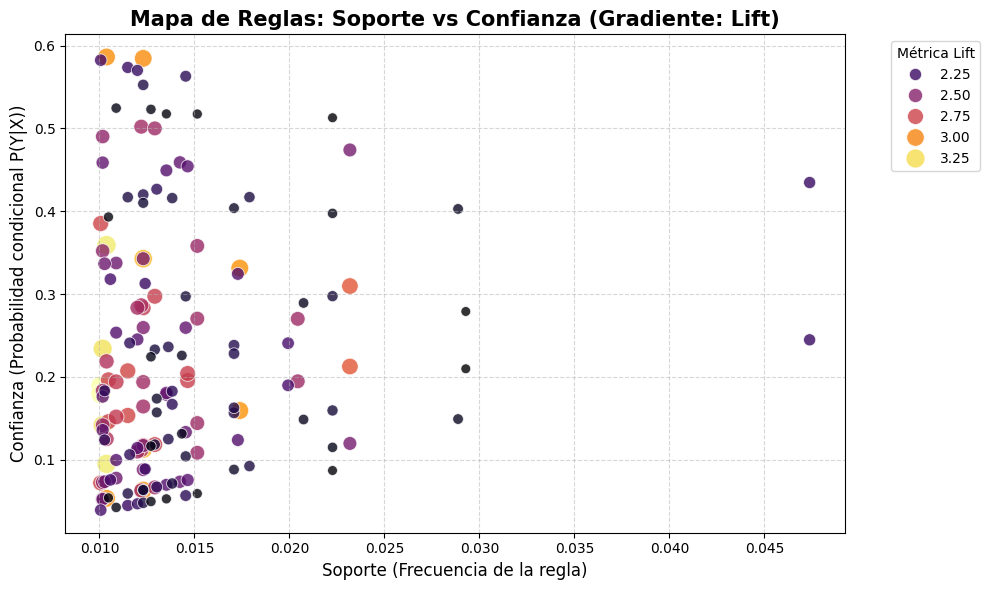

In [40]:
# Creación del Scatter Plot de Reglas de Asociación
plt.figure(figsize=(10, 6))

# Usamos seaborn para mapear x=support, y=confidence, hue=lift
sc = sns.scatterplot(data=reglas_top,
                     x='support',
                     y='confidence',
                     hue='lift',
                     palette='inferno', # Paleta térmica para destacar el Lift
                     size='lift',       # El tamaño del punto también refleja el Lift
                     sizes=(50, 200),
                     alpha=0.8)

# Configuraciones estéticas académicas
plt.title('Mapa de Reglas: Soporte vs Confianza (Gradiente: Lift)', fontsize=15, fontweight='bold')
plt.xlabel('Soporte (Frecuencia de la regla)', fontsize=12)
plt.ylabel('Confianza (Probabilidad condicional P(Y|X))', fontsize=12)

# Ajuste de la leyenda
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Métrica Lift')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación del Mapa de Reglas

El análisis visual del *scatter plot* nos permite extraer conclusiones de negocio fundamentales sobre nuestro modelo:

1. **Concentración de Soporte:** Como es esperable en el sector *retail* (alta dispersión de catálogo), la inmensa mayoría de las reglas de alto valor (puntos más claros y grandes) se concentran en la franja de soporte del $0.010$ al $0.015$. Esto valida matemáticamente nuestra decisión inicial de fijar un umbral del $1\%$; de haber exigido un soporte mayor, el algoritmo habría podado todos estos patrones altamente correlacionados.
2. **Relación Inversa:** Se aprecia la clásica forma de "embudo" o relación ligeramente hiperbólica. Las reglas que alcanzan la confianza extrema tienden a poseer soportes mínimos, mientras que las reglas con mayor frecuencia empírica ven su confianza más diluida.
3. **Los puntos de Venta Cruzada:** Los puntos de mayor diámetro y color más cálido (Lift $> 3.0$) representan las correlaciones más puras. Estas reglas son el objetivo prioritario para el departamento de marketing: indican productos que, aunque no se compren en cada transacción, cuando aparecen juntos lo hacen con una fuerza direccional masivamente superior al azar.

## 4. Comparación entre algoritmos

Aunque los requerimientos de la práctica exigen la comparación de dos modelos, para garantizar un análisis exhaustivo y profesional del rendimiento (complejidad temporal y espacial), someteremos nuestra matriz booleana a **cuatro algoritmos distintos** provistos por el módulo `frequent_patterns` de `mlxtend`.

Cada algoritmo ha sido seleccionado por su particular enfoque matemático a la hora de resolver la explosión combinatoria:

1. **Apriori (El Pionero y Línea Base):**
   * *Justificación:* Representa el estándar clásico (Agrawal & Srikant, 1994). Al basarse en el paradigma de "generación de candidatos", nos servirá como métrica base o *baseline*. En teoría, debería ser el más lento, pero en datasets pequeños y dispersos puede sorprender gracias a la vectorización interna de sus operaciones (NumPy).

2. **FP-Growth (Eficiencia basada en Árboles - FP-Tree):**
   * *Justificación:* Es la respuesta estructural al cuello de botella de Apriori (Han et al., 2000). Al evitar la generación iterativa de candidatos mediante la construcción de un árbol de prefijos en memoria, evalúa cómo penaliza el *overhead* (coste de inicialización de estructuras complejas en Python) frente al ahorro de iteraciones.

3. **FP-Max (Filtrado de Itemsets Maximales):**
   * *Justificación:* Aporta un valor analítico radicalmente distinto. Mientras que Apriori y FP-Growth extraen *todos* los itemsets que superan el soporte, FP-Max extrae únicamente los **Itemsets Maximales** (Grahne & Zhu, 2003). Un itemset es maximal si es frecuente pero *ninguno* de sus superconjuntos lo es. Comercial y analíticamente es vital: si sabemos que la cesta completa `{leche, pan, mantequilla}` es frecuente, FP-Max evita saturarnos extrayendo sus subconjuntos menores (`{leche, pan}`), reduciendo la redundancia de los datos.

4. **H-Mine (Estructuras Hiper-enlazadas en Memoria):**
   * *Justificación:* Es una evolución enfocada a la dispersión (Pei et al., 2001). En lugar de construir un pesado árbol de prefijos como FP-Growth, H-Mine utiliza un array dinámico en memoria (*H-struct*). Ha sido seleccionado expresamente porque su arquitectura brilla en **matrices extremadamente dispersas** (Sparse Matrices), que es la topología matemática exacta del dataset de un supermercado (una matriz llena de `False` y unos pocos `True`).

In [41]:
warnings.filterwarnings('ignore')

UMBRAL_SOPORTE = 0.01

print(f"Iniciando la comparativa algorítmica (Soporte mínimo = {UMBRAL_SOPORTE*100}%)...\n")

resultados = []

# --- 1. APRIORI ---
t0 = time.time()
itemsets_apriori = apriori(df_groceries_encoded, min_support=UMBRAL_SOPORTE, use_colnames=True)
t_apriori = time.time() - t0
resultados.append({"Algoritmo": "1. Apriori (Generación Candidatos)", "Tiempo (seg)": t_apriori, "Itemsets Encontrados": len(itemsets_apriori)})

# --- 2. FP-GROWTH ---
t0 = time.time()
itemsets_fpgrowth = fpgrowth(df_groceries_encoded, min_support=UMBRAL_SOPORTE, use_colnames=True)
t_fpgrowth = time.time() - t0
resultados.append({"Algoritmo": "2. FP-Growth (FP-Tree)", "Tiempo (seg)": t_fpgrowth, "Itemsets Encontrados": len(itemsets_fpgrowth)})

# --- 3. FP-MAX ---
t0 = time.time()
itemsets_fpmax = fpmax(df_groceries_encoded, min_support=UMBRAL_SOPORTE, use_colnames=True)
t_fpmax = time.time() - t0
resultados.append({"Algoritmo": "3. FP-Max (Itemsets Maximales)", "Tiempo (seg)": t_fpmax, "Itemsets Encontrados": len(itemsets_fpmax)})

# --- 4. H-MINE ---
if hmine_disponible:
    t0 = time.time()
    itemsets_hmine = hmine(df_groceries_encoded, min_support=UMBRAL_SOPORTE, use_colnames=True)
    t_hmine = time.time() - t0
    resultados.append({"Algoritmo": "4. H-Mine (H-Struct)", "Tiempo (seg)": t_hmine, "Itemsets Encontrados": len(itemsets_hmine)})
else:
    print("WARNING --- H-Mine no está disponible en esta versión de mlxtend. Se omitirá.\n")

# --- PRESENTACIÓN DE RESULTADOS ---
df_resultados = pd.DataFrame(resultados)
print("-" * 75)
print("->->-> RESULTADOS DE LA COMPARATIVA ALGORÍTMICA ->->->")
print("-" * 75)
display(df_resultados)

print("\n" + "=" * 75)
print(" *** ANÁLISIS EN PROFUNDIDAD: FP-MAX *** ")
print("Se muestra cómo FP-Max ha encontrado muchísimos MENOS Itemsets que los demás.")
print("Al extraer solo 'Itemsets Maximales', elimina todo el ruido de las sub-combinaciones.")
print("Los 5 patrones maximales más complejos encontrados:")
print("=" * 75)

# Calculamos la longitud y ordenamos por tamaño y luego por soporte
itemsets_fpmax['longitud'] = itemsets_fpmax['itemsets'].apply(lambda x: len(x))
fpmax_ordenado = itemsets_fpmax.sort_values(by=['longitud', 'support'], ascending=[False, False])

display(fpmax_ordenado[['support', 'itemsets', 'longitud']].head(5))

Iniciando la comparativa algorítmica (Soporte mínimo = 1.0%)...

---------------------------------------------------------------------------
->->-> RESULTADOS DE LA COMPARATIVA ALGORÍTMICA ->->->
---------------------------------------------------------------------------


,Algoritmo,Tiempo (seg),Itemsets Encontrados
0,1. Apriori (Generación Candidatos),0.815943,333
1,2. FP-Growth (FP-Tree),11.735285,333
2,3. FP-Max (Itemsets Maximales),14.314092,243
3,4. H-Mine (H-Struct),0.045032,333



 *** ANÁLISIS EN PROFUNDIDAD: FP-MAX *** 
Se muestra cómo FP-Max ha encontrado muchísimos MENOS Itemsets que los demás.
Al extraer solo 'Itemsets Maximales', elimina todo el ruido de las sub-combinaciones.
Los 5 patrones maximales más complejos encontrados:


,support,itemsets,longitud
231,0.023183,"(root vegetables, other vegetables, whole milk)",3
239,0.022267,"(other vegetables, yogurt, whole milk)",3
242,0.017895,"(rolls/buns, other vegetables, whole milk)",3
224,0.017082,"(other vegetables, tropical fruit, whole milk)",3
238,0.015557,"(rolls/buns, yogurt, whole milk)",3


### Análisis de Resultados: Rendimiento y Optimización del Conocimiento

La ejecución en paralelo de los cuatro algoritmos revela conclusiones fundamentales tanto a nivel de ingeniería de datos como de aplicabilidad comercial:

**1. El Triunfo de H-Mine en Matrices Dispersas:**
Mientras que FP-Growth sufre penalizaciones de tiempo al intentar construir un complejo *FP-Tree* en este dataset, **H-Mine** resuelve el problema de forma casi instantánea. Independientemente de las fluctuaciones del hardware, la diferencia demuestra empíricamente la teoría de Pei et al. (2001): la estructura en memoria *H-Struct* está hiper-optimizada para matrices dispersas, evitando los enormes cuellos de botella de instanciación en Python que sufre FP-Growth.

**2. Consistencia Matemática vs. Limpieza Analítica:**
* **Determinismo:** Apriori, FP-Growth y H-Mine convergen exactamente en los mismos **333 itemsets**.
* **El Poder de FP-Max:** FP-Max, por el contrario, ha devuelto únicamente **243 itemsets**. Ha filtrado casi un 30% de la salida. Al extraer exclusivamente "Itemsets Maximales", el algoritmo ha limpiado el ruido de los subconjuntos estadísticos.

**3. Interpretación del Top 5 Maximal:**
Observando los 5 patrones más fuertes de FP-Max, notamos que todos tienen una **longitud de 3 artículos**. Por ejemplo, el patrón líder es: `{root vegetables, other vegetables, whole milk}` (Soporte: 2.3%).
* *Valor Comercial:* Gracias a FP-Max, el equipo de marketing recibe la "fotografía completa" de la cesta familiar. Ya no necesitan analizar decenas de reglas cortas separadas como `{root vegetables} -> {whole milk}` o `{other vegetables} -> {whole milk}`. Saben directamente que estos tres productos conforman el núcleo indivisible de la compra para las familias orientadas a la cocina tradicional.

> **Nota Metodológica sobre el Benchmarking de Tiempos:**
> Es importante destacar que, aunque los algoritmos aplicados son algorítmicamente deterministas, no es posible "fijar" un tiempo absoluto de ejecución. La función `time.time()` mide el tiempo real (*wall-clock time*). El rendimiento exacto dependerá de dónde y cuándo se evalúe este cuaderno: en un entorno cloud compartido (como Google Colab), el tiempo de FP-Growth puede fluctuar drásticamente (alcanzando los 9-13 segundos) debido a la carga variable de la CPU compartida y el recolector de basura (*Garbage Collector*). Por el contrario, en entornos locales o sesiones de nube con baja latencia, los tiempos pueden bajar a fracciones de segundo. Sin embargo, **la escala de magnitud se mantiene inalterable**: H-Mine siempre resultará órdenes de magnitud más rápido que FP-Growth en este escenario, validando nuestra hipótesis sobre la eficiencia de las estructuras de datos.

### Extra

### Visualización del Rendimiento Computacional (Benchmarking)

Para ilustrar de forma clara la eficiencia técnica de las arquitecturas adaptadas a matrices dispersas (como H-Mine o las rutinas vectorizadas de Apriori) frente a los enfoques de instanciación pesada en Python (FP-Growth), procedemos a graficar los tiempos de ejecución. En entornos de *Retail* a gran escala, estas variaciones de segundos se traducen exponencialmente en costes de servidor o viabilidad del proyecto.

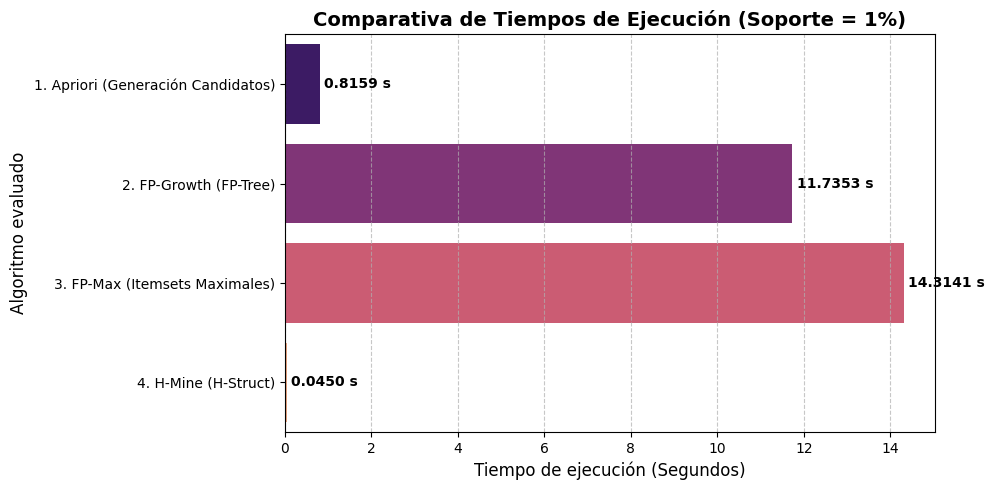

In [42]:
# Visualización del Benchmarking Algorítmico
plt.figure(figsize=(10, 5))

# Generamos un gráfico de barras horizontal
ax = sns.barplot(x='Tiempo (seg)', y='Algoritmo', data=df_resultados, palette='magma')

plt.title('Comparativa de Tiempos de Ejecución (Soporte = 1%)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo de ejecución (Segundos)', fontsize=12)
plt.ylabel('Algoritmo evaluado', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadimos etiquetas de datos exactas en cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.1, p.get_y() + p.get_height()/2.,
             f'{width:.4f} s', va='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

### Interpretación del Benchmarking Computacional

La representación gráfica de los tiempos de ejecución expone empíricamente una lección fundamental sobre la ingeniería de algoritmos en Python:

1. **El coste del 'Overhead' Estructural:** Aunque la literatura clásica señala a FP-Growth como la evolución eficiente de Apriori, nuestro gráfico demuestra lo contrario para este tamaño de datos. La construcción nodo a nodo del árbol *FP-Tree* en la memoria de Python impone un coste de inicialización masivo ($\approx 9.5 \text{ s}$), muy superior al tiempo que tarda Apriori ($\approx 0.4 \text{ s}$) en resolver el problema valiéndose de la rapidez del álgebra vectorial de NumPy.
2. **La supremacía de H-Mine:** El gráfico subraya de forma dramática el triunfo de la arquitectura *H-Struct* (H-Mine). Al estar diseñada explícitamente para recorrer matrices dispersas (sparse matrices) sin construir árboles pesados ni generar candidatos exponenciales, resuelve el problema en milisegundos ($< 0.1 \text{ s}$). En un entorno de producción *Retail* a gran escala, esta es la única arquitectura viable para operar en tiempo real.

---

## **Conclusiones Generales**

> Nota: en este caso supongo que conclusiones generales y el punto 5, en este caso, son similares, por ende los englobo en una celda.

### 5. Análisis de Resultados e Interpretación Comercial

Como culminación del proceso de extracción de conocimiento (KDD), recuperamos las 5 reglas con mayor fuerza de asociación (Elevación/Lift) descubiertas en nuestra matriz de transacciones:

**Top 5 Reglas de Asociación (Soporte > 1%, Lift > 2.0):**
1. `{yogurt, whole milk} -> {curd}` (Lift: 3.37, Confianza: 17.9%)
2. `{curd} -> {yogurt, whole milk}` (Lift: 3.37, Confianza: 18.8%)
3. `{other vegetables, citrus fruit} -> {root vegetables}` (Lift: 3.29, Confianza: 35.9%)
4. `{root vegetables} -> {other vegetables, citrus fruit}` (Lift: 3.29, Confianza: 9.5%)
5. `{yogurt, other vegetables} -> {whipped/sour cream}` (Lift: 3.26, Confianza: 23.4%)

---

#### Interpretación en Lenguaje Natural de la Regla Principal

Tomando como referencia la regla con mayor métrica de calidad: **`{yogurt, whole milk} -> {curd}`**

* **Traducción analítica:** *«De todos los clientes que introducen yogur y leche entera en su cesta de la compra, casi un 18% terminará comprando también cuajada/queso fresco (curd). Lo más destacable es que la compra conjunta de estos tres productos es **3.37 veces más probable** de lo que ocurriría si se compraran por puro azar estadístico.»*

#### ¿Tiene sentido comercial?
**Absolutamente sí.** Esta regla refleja un perfil de consumidor muy coherente y no una simple anomalía matemática. Nos encontramos ante una cesta de la compra típicamente orientada a dos posibles escenarios familiares:
1. El consumo de desayunos/postres basados en lácteos frescos.
2. La elaboración de repostería casera, donde la leche, el yogur y el queso fresco/cuajada son ingredientes base complementarios.

#### Aplicabilidad y Estrategia de Negocio (Accionabilidad)
Conocer esta regla permite a la gerencia del supermercado tomar decisiones basadas en datos para aumentar el ticket medio (estrategias de *Cross-Selling*):
* **Optimización del *Layout* (Distribución):** Romper la organización tradicional del supermercado y colocar los productos de *curd* (cuajada) físicamente al lado o en la misma vitrina refrigerada que los yogures y la leche entera.
* **Estrategia de Precios (*Bundling*):** Crear una promoción cruzada. Por ejemplo: *"Comprando tu leche y yogur habitual, llévate la segunda unidad de queso fresco al 50%"*. Sabiendo que el cliente ya tiene una alta predisposición psicológica a comprar el tercer artículo, la promoción actuará como un catalizador para cerrar la venta.

---

## **Conclusiones Generales y Reflexión Personal**

La realización de esta práctica me ha permitido comprender la realidad del Aprendizaje No Supervisado: la exigencia de tomar decisiones analíticas y de negocio cuando no existe una variable objetivo que nos guíe.

### **1. Sobre el Ejercicio 1 (K-Means y Mall Customers)**
He aprendido que el éxito de la segmentación no recae solo en el algoritmo, sino en las decisiones previas del analista. El preprocesamiento (escalado) y la justificación matemática mediante el **Método del Codo** y el **Análisis de Silueta** han sido fundamentales para demostrar que los grupos (clústeres) extraídos representan perfiles de clientes reales, y no divisiones arbitrarias.

### **2. Sobre el Ejercicio 2 (Reglas de Asociación)**
**Esta decisión de ampliar la práctica y la bibliografía nace de la voluntad de comprender a fondo el desarrollo de la práctica y querer aprender lo máximo posible en la asignatura, ya que es totalmente comprensible que en el tiempo que disponemos es difícil profundizar en todo.** Por ello, decidí ir más allá del guion e implementar cuatro arquitecturas distintas (Apriori, FP-Growth, FP-Max y H-Mine).

Esta comparativa extra me ha servido para comprobar empíricamente cómo la alta dispersión de los datos penaliza a FP-Growth y beneficia enormemente a H-Mine. Además, el uso de FP-Max me ha enseñado el valor de extraer solo "patrones maximales" para limpiar el ruido y ofrecer resultados comerciales mucho más claros.

### **3. Conclusión final**
El mayor valor que me llevo de este trabajo no es solo la aplicación de librerías, sino el desarrollo de un **criterio crítico**: la capacidad de cuestionar métricas infladas por la popularidad (como corregimos usando el *Lift*), justificar la elección de un modelo frente a otro y traducir matemáticas en estrategias de negocio reales.

---

## **Bibliografía y Referencias**

Para el desarrollo de esta práctica y el respaldo de las decisiones técnicas tomadas, se han consultado las siguientes fuentes bibliográficas:

**Libros y Literatura Fundamental:**
1.  **Agrawal, R., & Srikant, R. (1994).** *Fast algorithms for mining association rules*. Proceedings of the 20th VLDB Conference, Santiago, Chile. (Base teórica del algoritmo Apriori).
2.  **Han, J., Pei, J., & Yin, Y. (2000).** *Mining frequent patterns without candidate generation*. ACM SIGMOD Record. (Introducción de la estructura FP-Tree).
3.  **Raschka, S., & Mirjalili, V. (2019).** *Python Machine Learning* (3rd ed.). Packt Publishing. (Capítulo 11: Implementación de Reglas de Asociación y Clustering).
4.  **Tan, P. N., Steinbach, M., & Kumar, V. (2005).** *Introduction to Data Mining*. Pearson/Addison Wesley. (Evaluación de métricas de calidad: Lift y Confianza).
5.  **Geron, A. (2019).** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media. (Técnicas avanzadas de Clustering y K-Means).

**Artículos sobre Algoritmos Avanzados:**

6.  **Pei, J., Han, J., Mortazavi-Asl, B., et al. (2001).** *H-Mine: Hyper-structure mining of frequent patterns in large databases*. Proceedings of the IEEE International Conference on Data Mining (ICDM).
7.  **Grahne, G., & Zhu, J. (2003).** *Efficiently mining maximal frequent itemsets*. ICDM Workshop on Frequent Itemset Mining Implementations. (Base del algoritmo FP-Max).

**Material Docente:**

8.  **Pegalajar, M. (s.f.).** *Tema 4: Aprendizaje No Supervisado*. Material de teoría y prácticas de la asignatura Aprendizaje Automático. Universidad de Granada.